
<div style="background-color: #2C2927; padding: 0px; border-radius: 0px; border: 0px solid #add8e6;">

# <span style="color:#C9A188;"><center>**Final Project**</center></span>
<center>Prediksi Harga Mobil Bekas di Arab Saudi Menggunakan Model Machine Learning</center>
<div align="center"><span style="color:grey">

<small>JCDSAH-025-Gamma Group</small>
</span>
</div>
</div>

# **Business Problem**

## Problem Background

Syarah.com merupakan platfrom untuk jual beli mobil bekas yang berbasis di Arab Saudi. Syarah.com berperan sebagai pihak ketiga yang akan membeli mobil bekas dari seller yang telah mendaftarkan mobilnya pada situs dan memberikan tawaran harga jika mobil lolos proses inspeksi. Mobil yang berhasil dibeli akan dimasukan pada situs untuk dijual kembali kepada buyer.

Berikut merupakan proses bisnis dari transaksi penjualan mobil bekas oleh seller kepada Syarah.com

![image.png](Business_Process_Flow_chart.png)

Seller perlu melewati proses inspeksi sebelum perusahaan menetapkan harga mobil dan memberikan tawaran kepada seller. Proses inspeksi membutuhkan biaya, sehingga penjualan mobil yang dibatalkan oleh seller berdampak pada kerugian dari segi material dan waktu.

Terdapat banyak sekali faktor yang menentukan harga suatu mobil bekas, penjual yang tidak memiliki acuan yang jelas akan mengalami kesulitan dalam menentukan apakah harga yang ditentukan oleh Syarah.com akan sesuai dengan keinginan penjual.

Mobil yang memiliki harga terlalu tinggi dari nilainya tidak dapat terjual di platform sedangkan mobil yang terlalu murah membuat perusahaan tidak mendapatkan profit yang sepadan. Pemberian harga mobil bekas tanpa refrensi yang berkaca dari pasar berujung pada penurunan tingkat kepercayaan pengguna situs. Hal ini juga dapat berdampak pada munculnya persepsi konsumen terhadap situs Syarah.com sebagai situs yang tidak kredibel. 

## Problem Statement

Harga mobil yang tidak sesuai memunculkan persepsi buruk terhadap platform sehingga tingkat kepercayaan konsumen berkurang dan platform dapat dianggap sebagai situs jual beli mobil bekas yang tidak kredibel. Perusahaan butuh memberikan fitur estimasi harga ketika penjual mendaftarkan mobil yang ingin dijual sebagai solusi dalam permasalahan tersebut, namun prediksi tidak dapat dilakukan secara sederhana. Harga suatu mobil bekas tidak hanya ditentukan dengan satu atau dua faktor, terdapat kompleksitas yang tidak dapat ditangkap oleh metode konvensional.

**Bagaimana membangun sistem estimasi harga mobil bekas yang memiliki spesifikasi tertentu dengan tingkat kesalahan rendah sebagai acuan untuk penjual dan meningkatkan tingkat kepercayaan konsumen terhadap situs jual beli mobil bekas ?**

## Goals

Berdasarkan Problem Statement yang ada, project ini memiliki dua tujuan, yaitu:

1. Prediksi harga mobil

Prediksi harga mobil dilakukan dengan membangun model machine learning regresi dengan tingkat kesalahan rendah 

2. Analisis faktor yang mempengaruhi harga mobil

Identifikasi faktor yang paling mempengaruhi harga mobil, seperti tahun pembuatan, jenis bahan bakar, jarak tempuh mobil, dan lain-lain

## Analytic Approach

Dalam menjawab pertanyaan bisnis dan mencapai tujuan dari project ini, kita akan melakukan analisa data listing mobil pada platform jual beli untuk menemukan pola dari fitur-fitur yang membedakan mobil satu dengan mobil lainnya.

Selanjutnya, kita akan membangun model machine learning regresi yang dapat diimplementasikan perusahaan sebagai alat prediksi harga mobil bekas. Model tersebut dapat dimanfaatkan oleh penjual dalam menentukan harga mobil ketika mendaftarkan mobilnya pada situs jual beli.

## Evaluation Metrics

Metrik evaluasi yang digunakan untuk menilai performa model machine learning yang akan dibangun adalah RMSE, MAE, dan MAPE.

1. RMSE

RMSE merupakan nilai akar dari rata-rata kuadrat error yang dibuat model. Semakin ekstrim suatu nilai error maka nilai RMSE akan semakin tinggi. Metrik ini memberikan bobot berdasarkan ukuran error sehingga dapat mengukur seberapa akurat model melakukan prediksi ketika terdapat outlier pada error.

- **Dampak bisnis** : Prediksi yang tidak tepat terhadap harga mobil dengan nilai pasar yang sangat tinggi atau rendah membangun persepsi konsumen yang buruk terhadap kemampuan situs dalam mengidentifikasi mobil mewah dan mobil murah.

- **Target** : RMSE < 20000

2. MAE

MAE merupakan nilai rata-rata absolut error yang dihasilkan model tanpa mempertimbangkan outlier dan arah prediksi sehingga lebih mudah untuk interpretasi model.

- **Dampak bisnis** : prediksi yang terlalu rendah dari nilai aktual (underpricing) dapat menurunkan kemungkinan penjual mendaftarkan mobilnya pada situs, sedangkan prediksi yang terlalu tinggi dari nilai aktual dapat menurunkan kemungkinan mobil terjual dan mengendap di inventory.

- **Target** : MAE < 15000

3. MAPE

MAPE merupakan persentase error dari model, metrik ini dapat mengukur seberapa besar model melakukan kesalahan dalam melakukan prediksi.

- **Dampak bisnis** : persentase error yang tinggi berarti akurasi pada prediksi yang dihasilkan model terhadap semua mobil rendah. Hal ini membuat tingkat kepercayaan penjual terhadap akurasi fitur menjadi kecil.

- **Target** : MAPE < 20%


## Refrence

- https://syarah.com/carsguide/en/how-sell-car-saudi-arabia/?__cf_chl_f_tk=7zUT6KcmxmFOq9OPc9VcCYq7gSQkBSBzlwpGFmlmrr0-1783084660-1.0.1.1-..iHDRxAn5JvENrVoxseyvS7qXBAc9B_eyI4pgnHEdE
- https://syarah.com/carsguide/en/car-inspection-price-saudi-arabia/
- https://www.researchgate.net/publication/257812432_Using_the_R-MAPE_index_as_a_resistant_measure_of_forecast_accuracy

# **Data Understanding**

### Import Libraries

In [79]:
#import base
import pandas as pd
import numpy as np
import re
import missingno
import json

#import visualization tools
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

#import preprocess tools
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler, StandardScaler, MinMaxScaler
from category_encoders import BinaryEncoder, target_encoder
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, KFold, learning_curve, LearningCurveDisplay

#import metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

#Import regressor model
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost.sklearn import XGBRegressor

#Import model interpretability tools
import shap
from sklearn.inspection import permutation_importance
import scipy

#import model deployment tools
import joblib
from statsmodels import api as sm

- Dataset merupakan data listing mobil bekas yang didapatkan melalui web scraping di platform Syarah.com pada tahun 2021.
- Setiap baris data merepresentasikan informasi terkait properti dan pemiliknya.

**Attributes Information**

| **Attribute** | **Data Type** | **Description** |
| --- | --- | --- |
| Make | String | Merk Mobil |
| Type | String | Tipe model mobil |
| Year | Integer | Tahun pembuatan |
| Origin | String | Asal negara mobil |
| Color | String | Warna mobil |
| Options | String | Tipe pilihan mobil |
| Engine_Size | Float | Ukuran mesin |
| Fuel_Type | String | Jenis bahan bakar |
| Gear_Type | String | Jenis transmisi mobil |
| Mileage | Integer | Riwayat jarak tempuh dalam KM |
| region | String | Asal area mobil |
| Price | Integer | Harga mobil |
| Negotiable | Boolean | Ketersediaan negosiasi |

In [80]:
df = pd.read_csv('dataset/UsedCarsSA_Clean_EN.csv')
df

,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Mileage,Region,Price,Negotiable
0,Chrysler,C300,2018,Saudi,Black,Full,5.7,Gas,Automatic,103000,Riyadh,114000,False
1,Nissan,Patrol,2016,Saudi,White,Full,4.8,Gas,Automatic,5448,Riyadh,0,True
2,Nissan,Sunny,2019,Saudi,Silver,Standard,1.5,Gas,Automatic,72418,Riyadh,27500,False
3,Hyundai,Elantra,2019,Saudi,Grey,Standard,1.6,Gas,Automatic,114154,Riyadh,43000,False
4,Hyundai,Elantra,2019,Saudi,Silver,Semi Full,2.0,Gas,Automatic,41912,Riyadh,59500,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8030,Audi,A6,2015,Saudi,Silver,Full,3.0,Gas,Automatic,77000,Riyadh,75000,False
8031,Chevrolet,Camaro,2010,Saudi,Silver,Full,3.6,Gas,Automatic,150000,Riyadh,53000,False
8032,Toyota,Land Cruiser,2013,Gulf Arabic,White,Full,4.6,Gas,Automatic,260,Najran,0,True
8033,Nissan,Altima,2011,Saudi,Silver,Full,2.5,Gas,Automatic,18500,Aseer,22000,False


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8035 entries, 0 to 8034
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Make         8035 non-null   object 
 1   Type         8035 non-null   object 
 2   Year         8035 non-null   int64  
 3   Origin       8035 non-null   object 
 4   Color        8035 non-null   object 
 5   Options      8035 non-null   object 
 6   Engine_Size  8035 non-null   float64
 7   Fuel_Type    8035 non-null   object 
 8   Gear_Type    8035 non-null   object 
 9   Mileage      8035 non-null   int64  
 10  Region       8035 non-null   object 
 11  Price        8035 non-null   int64  
 12  Negotiable   8035 non-null   bool   
dtypes: bool(1), float64(1), int64(3), object(8)
memory usage: 761.3+ KB


In [82]:
df.describe()

,Year,Engine_Size,Mileage,Price
count,8035.000000,8035.000000,8.035000e+03,8.035000e+03
mean,2014.097698,3.287729,1.491488e+05,5.369984e+04
std,5.757228,1.517747,3.474480e+05,7.198472e+04
min,1963.000000,1.000000,1.000000e+02,0.000000e+00
25%,2012.000000,2.000000,3.700000e+04,0.000000e+00
50%,2016.000000,3.000000,1.019600e+05,3.700000e+04
75%,2018.000000,4.400000,1.950000e+05,7.375000e+04
max,2022.000000,9.000000,2.000000e+07,1.150000e+06


In [83]:
df.shape

(8035, 13)

Dataset memiliki 8035 baris data dengan 13 kolom

## Missing Data

In [84]:
missingno.matrix(df)

<Axes: >

In [85]:
df.isna().sum()

Make           0
Type           0
Year           0
Origin         0
Color          0
Options        0
Engine_Size    0
Fuel_Type      0
Gear_Type      0
Mileage        0
Region         0
Price          0
Negotiable     0
dtype: int64

In [86]:
df_negotiable = df[df['Negotiable']==True]
df_non_negotiable = df[df['Negotiable']==False]

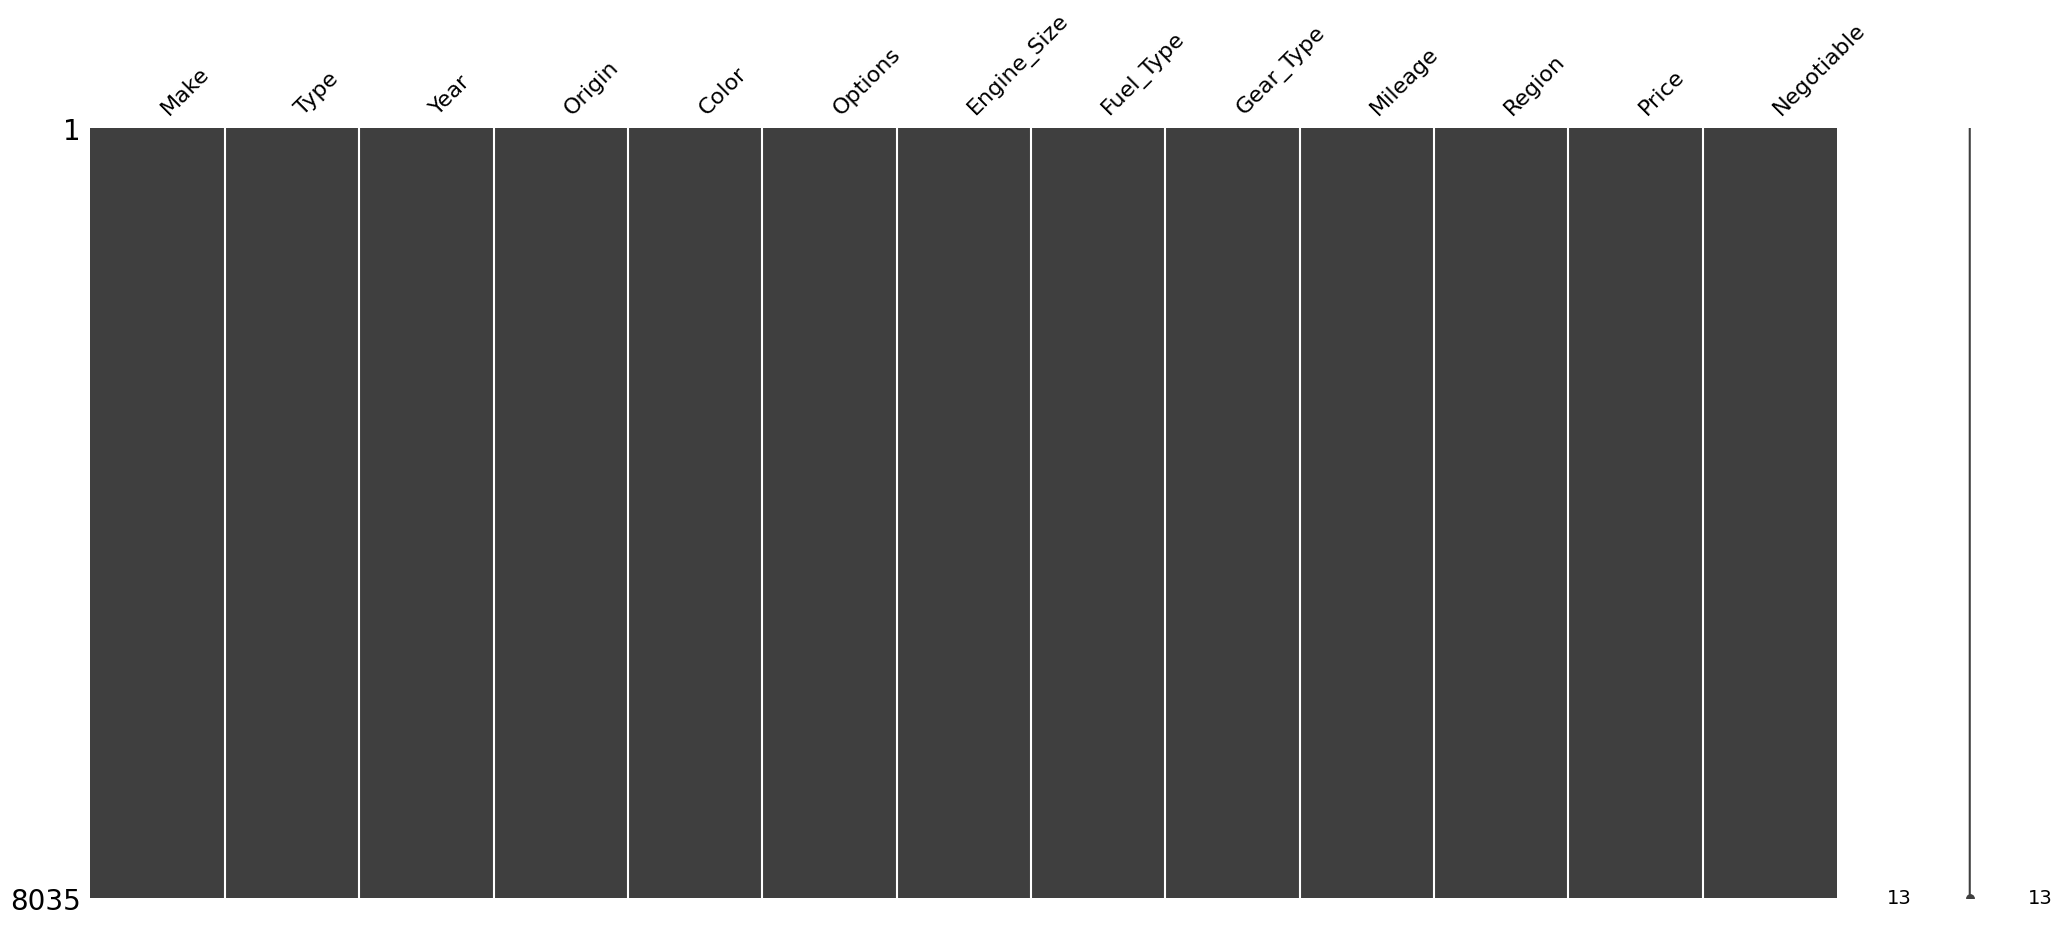

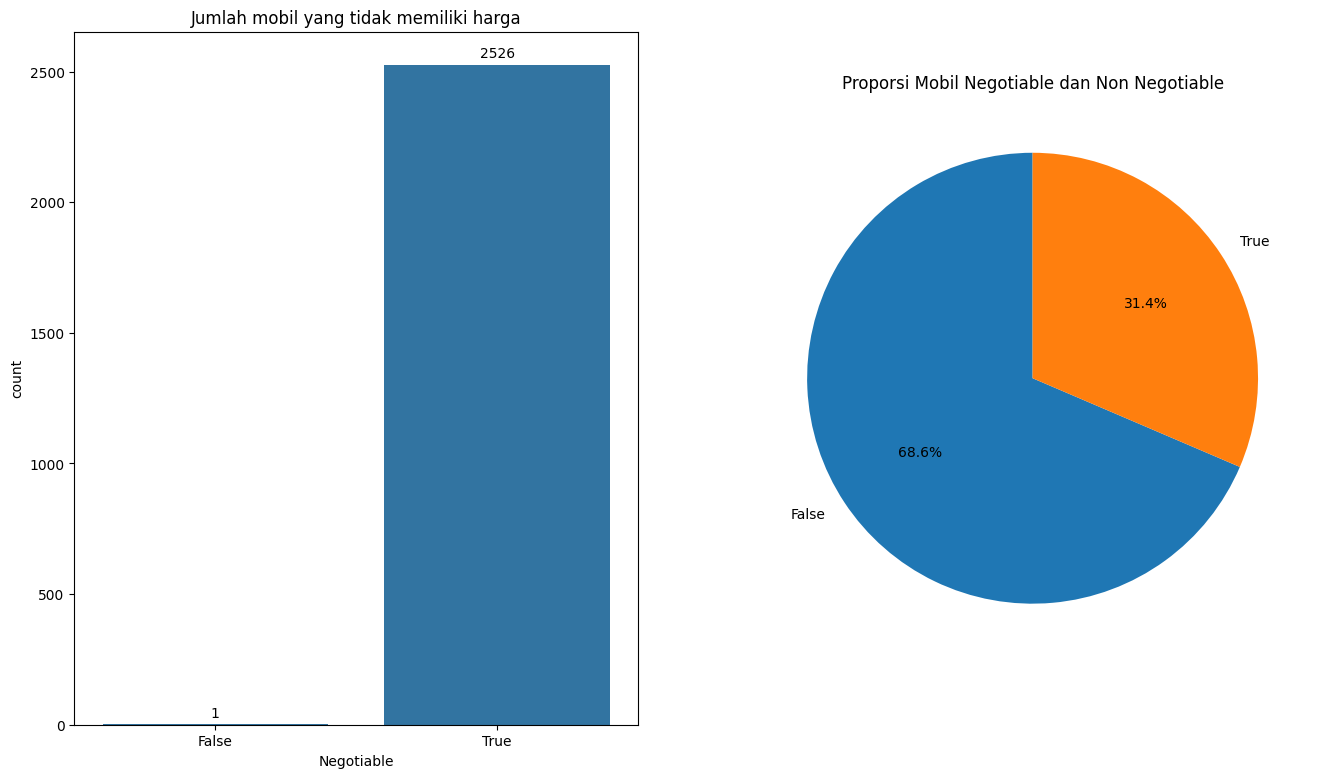

In [87]:
df_nego_count = df.groupby('Negotiable')['Price'].count().reset_index()

fig, axes = plt.subplots(nrows=1,ncols=2, figsize=(16,9))

bar = sns.countplot(data=df[df['Price']==0], x='Negotiable', ax=axes[0])
axes[0].bar_label(bar.containers[0], padding=3)

axes[1].pie(df_nego_count['Price'], labels=df_nego_count['Negotiable'], autopct='%1.1f%%', startangle=90)

axes[0].set_title("Jumlah mobil yang tidak memiliki harga")
axes[1].set_title("Proporsi Mobil Negotiable dan Non Negotiable")

plt.show()

In [88]:
missing_val_total = (df['Price']==0).sum()
missing_val_nego = (df_negotiable['Price']==0).sum()
missing_val_non = (df_non_negotiable['Price']==0).sum()

missing_val_total_pct = (missing_val_total/len(df))*100
missing_val_nego_pct = (missing_val_nego/len(df_negotiable))*100
missing_val_non_pct = (missing_val_non/len(df_non_negotiable))*100


print(f"{missing_val_total} dari total data merupakan missing value, sebesar {missing_val_total_pct}")
print(f"{missing_val_nego} dari total data mobil yang merupakan negotiable merupakan missing value, sebesar {missing_val_nego_pct}")
print(f"{missing_val_non} dari total data mobil yang merupakan non negotiable merupakan missing value, sebesar {missing_val_non_pct}")

2527 dari total data merupakan missing value, sebesar 31.44990665836963
2526 dari total data mobil yang merupakan negotiable merupakan missing value, sebesar 100.0
1 dari total data mobil yang merupakan non negotiable merupakan missing value, sebesar 0.01815211472136504


- Terdapat 2527 baris data pada kolom Price yang bernilai 0
- 31% dataset merupakan missing data
- Semua data mobil negotiable tidak memiliki harga
- Terdapat satu baris data mobil non negotiable yang memiliki harga 0

In [89]:
df_eda = df[df['Negotiable']==False]
df_eda.drop(columns=['Negotiable'], inplace=True)

df_eda.replace({'Price':0}, np.nan, inplace=True)
df_eda['Price'] = df_eda.groupby('Make')['Price'].transform(lambda x: x.fillna(x.median()))

C:\Users\dwisanjani\AppData\Local\Temp\ipykernel_38644\2304040468.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eda.drop(columns=['Negotiable'], inplace=True)
C:\Users\dwisanjani\AppData\Local\Temp\ipykernel_38644\2304040468.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eda.replace({'Price':0}, np.nan, inplace=True)
C:\Users\dwisanjani\AppData\Local\Temp\ipykernel_38644\2304040468.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cave

- Mobil yang dijual dengan opsi negosiasi yang tersedia tidak memiliki harga, sedangkan harga merupakan variabel target yang akan diprediksi oleh model sehingga kita hanya akan menggunakan data dengan mobil yang tidak dapat negosiasi.
- Mobil non negotiable yang memiliki harga 0 akan diisi dengan nilai median sesuai dengan merk mobilnya

In [90]:
num_cols = ['Year','Engine_Size','Mileage','Price']
df_eda_cat = df_eda.drop(columns=num_cols)

df_eda_cat.nunique()

Make          57
Type         352
Origin         4
Color         15
Options        3
Fuel_Type      3
Gear_Type      2
Region        27
dtype: int64

In [91]:
unique_values_series = pd.Series({col: df_eda_cat[col].unique() for col in df_eda_cat})

with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    print(unique_values_series)

Make                                                                                                                                                                                                                                                                                               [Chrysler, Nissan, Hyundai, Honda, Toyota, Chevrolet, Mercedes, MINI, Lexus, Land Rover, GMC, Mazda, Ford, Kia, Genesis, Cadillac, Geely, MG, Jeep, INFINITI, Dodge, Ferrari, Great Wall, Jaguar, GAC, Renault, Suzuki, Peugeot, Changan, HAVAL, BMW, Rolls-Royce, Porsche, Mitsubishi, Subaru, Zhengzhou, Lincoln, Daihatsu, FAW, Chery, Isuzu, Audi, Bentley, Aston Martin, Volkswagen, Fiat, Mercury, Classic, Hummer, BYD, Maserati, Other, Lifan, Foton, Victory Auto, Škoda, Iveco]
Type         [C300, Sunny, Elantra, Accord, Land Cruiser, Impala, Yaris, Camry, Patrol, Tahoe, CLA, E, Corolla, Copper, Prado, Civic, Furniture, RX, Range Rover, Yukon, Bus Urvan, Aurion, Malibu, Rav4, CX9, Expedition, ES, Cadenza, Tuc

In [92]:
df_eda['Origin'].unique()

array(['Saudi', 'Gulf Arabic', 'Other', 'Unknown'], dtype=object)

Terdapat missing value berupa 'unknown' pada kolom origin

In [93]:
print(f"Terdapat {(df_eda['Origin']=='Unknown').sum()} baris data yang memiliki origin 'unknown'")
df_eda[df_eda['Origin']=='Unknown']

Terdapat 24 baris data yang memiliki origin 'unknown'


,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Mileage,Region,Price
1437,Ford,Expedition,2015,Unknown,Black,Semi Full,5.4,Gas,Automatic,125000,Jeddah,75000.0
1705,Toyota,Land Cruiser,2018,Unknown,White,Full,5.7,Gas,Automatic,59000,Riyadh,275000.0
2626,Mercury,Grand Marquis,2007,Unknown,Silver,Full,4.6,Gas,Automatic,179000,Al-Medina,24000.0
3016,Dodge,Charger,2020,Unknown,Grey,Full,3.6,Gas,Automatic,9120,Riyadh,115000.0
3026,Hyundai,Sonata,2016,Unknown,Another Color,Semi Full,2.4,Gas,Automatic,258000,Al-Ahsa,38000.0
3028,Lexus,ES,2021,Unknown,Silver,Full,3.5,Gas,Automatic,1300,Jeddah,175000.0
3620,Toyota,Camry,2017,Unknown,White,Standard,2.5,Gas,Automatic,120000,Abha,59000.0
3656,Toyota,Land Cruiser,2020,Unknown,White,Full,4.6,Gas,Automatic,43000,Riyadh,265000.0
4291,Ford,Taurus,2014,Unknown,White,Standard,3.5,Gas,Automatic,266000,Taef,50000.0
4293,Chevrolet,Traverse,2014,Unknown,Black,Standard,3.6,Gas,Automatic,195000,Riyadh,42000.0


24 baris data memiliki missing value pada kolom origin. Langkah selanjutnya adalah menghapus semua baris tersebut untuk keperluan analisa

In [94]:
df_eda.replace({'Origin':'Unknown'}, np.nan, inplace=True)
df_eda.dropna(axis=0, inplace=True)

C:\Users\dwisanjani\AppData\Local\Temp\ipykernel_38644\2878991789.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eda.replace({'Origin':'Unknown'}, np.nan, inplace=True)
C:\Users\dwisanjani\AppData\Local\Temp\ipykernel_38644\2878991789.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eda.dropna(axis=0, inplace=True)


## Duplicated Data

In [95]:
df_eda.duplicated().sum()

np.int64(2)

In [96]:
df_eda[df_eda.duplicated(keep='first')]

,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Mileage,Region,Price
2027,Ford,Taurus,2015,Other,Red,Full,3.5,Gas,Automatic,122000,Dammam,69000.0
3201,Ford,Taurus,2019,Other,Red,Semi Full,3.5,Gas,Automatic,108000,Dammam,97000.0


Terdapat 2 baris data yang merupakan data duplikat, namun kedua baris data tersebut memiliki value yang berbeda, maka data-data tersebut tidak akan dihapus

## Exploratory Data Analysis

In [97]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5485 entries, 0 to 8034
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Make         5485 non-null   object 
 1   Type         5485 non-null   object 
 2   Year         5485 non-null   int64  
 3   Origin       5485 non-null   object 
 4   Color        5485 non-null   object 
 5   Options      5485 non-null   object 
 6   Engine_Size  5485 non-null   float64
 7   Fuel_Type    5485 non-null   object 
 8   Gear_Type    5485 non-null   object 
 9   Mileage      5485 non-null   int64  
 10  Region       5485 non-null   object 
 11  Price        5485 non-null   float64
dtypes: float64(2), int64(2), object(8)
memory usage: 557.1+ KB


Setelah melakukan trimming pada data yang tidak dibutuhkan, ukuran dari dataset yang akan kita gunakan untuk tahapan selanjutnya memiliki 5485 baris dan 12 kolom.

### Distribusi Harga Mobil

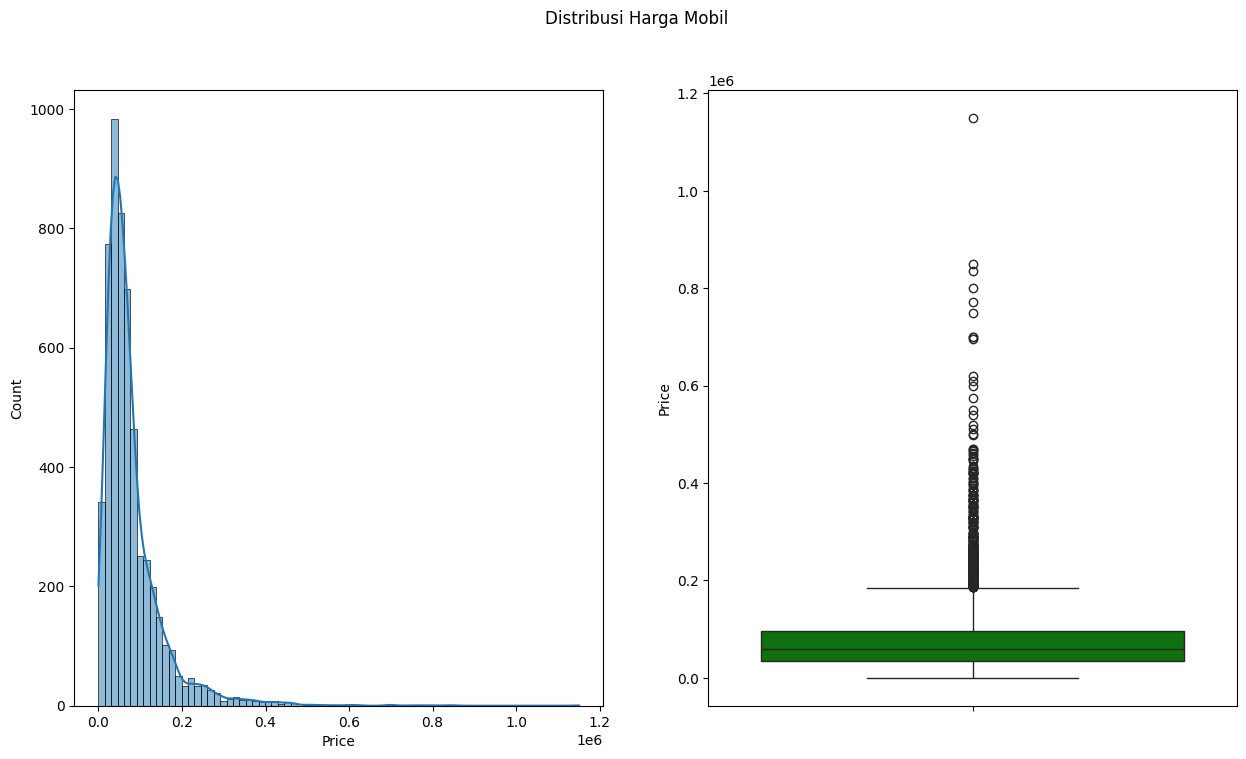

In [98]:
fig, axes = plt.subplots(1,2,figsize=(15,8))

sns.histplot(df_eda['Price'], bins=75, kde=True, ax=axes[0])
sns.boxplot(df_eda['Price'], ax=axes[1], color='green')


plt.suptitle("Distribusi Harga Mobil")

plt.show()

- Berdasarkan plot histogram distribusi harga mobil bekas yang ada pada Syarah.com, terlihat bahwa data terdistribusi secara tidak normal. Terdapat 'Positive Skewness' pada variable harga.
- Berdasarkan boxplot harga mobil, terdapat outlier yang melewati batas upper bound

In [99]:
df_eda['Price'].describe().reset_index().style.format({'Price': '{:.2f}'})

,index,Price
0,count,5485.00
1,mean,78375.46
2,std,75033.33
3,min,1.00
4,25%,35000.00
5,50%,58000.00
6,75%,95000.00
7,max,1150000.00


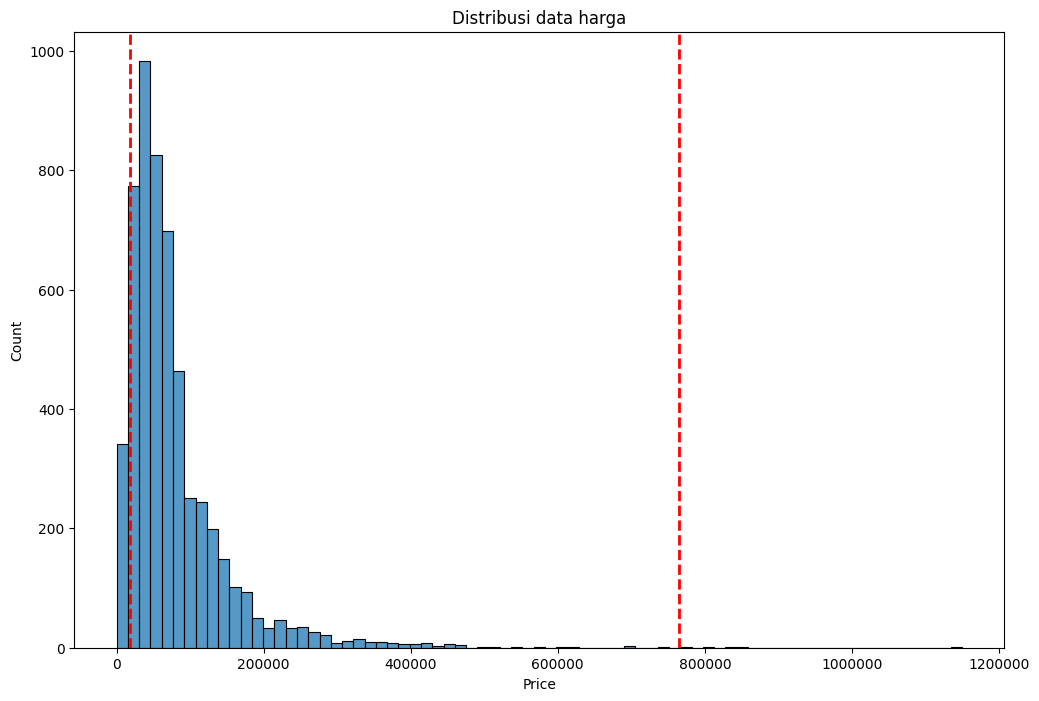

In [100]:
plt.figure(figsize=(12,8))

ax = sns.histplot(df_eda['Price'], bins=75)
plt.axvline(x=18500, color="red", linestyle="--", linewidth=2, label="Threshold")
plt.axvline(x=765000, color="red", linestyle="--", linewidth=2, label="Threshold")

plt.title("Distribusi data harga")
plt.ticklabel_format(style='plain', axis='both')

plt.show()

- Mobil bekas dengan harga terkecil adalah 1 SAR, sedangkan yang termahal adalah 1150000 SAR
- Berdasarkan situs Syarah.com, mobil yang dijual pada situs tersebut hanya memiliki jangkauan harga 18500 SAR - 765000 SAR

### Consumer Behaviour

#### Analisis Brand Mobil

In [101]:
df_make = df_eda.groupby('Make')['Price'].agg(['median', 'count']).rename(columns={'median': 'Median_Price', 'count': 'Count'}).reset_index()
df_make = df_make.sort_values(by='Median_Price', ascending=False)
df_make.head(10)

,Make,Median_Price,Count
49,Rolls-Royce,560000.0,4
0,Aston Martin,400000.0,3
4,Bentley,310000.0,7
14,Ferrari,280000.0,1
33,Land Rover,240000.0,75
30,Jaguar,155000.0,11
39,Maserati,148250.0,6
41,Mercedes,145000.0,256
34,Lexus,141500.0,236
47,Porsche,138000.0,25


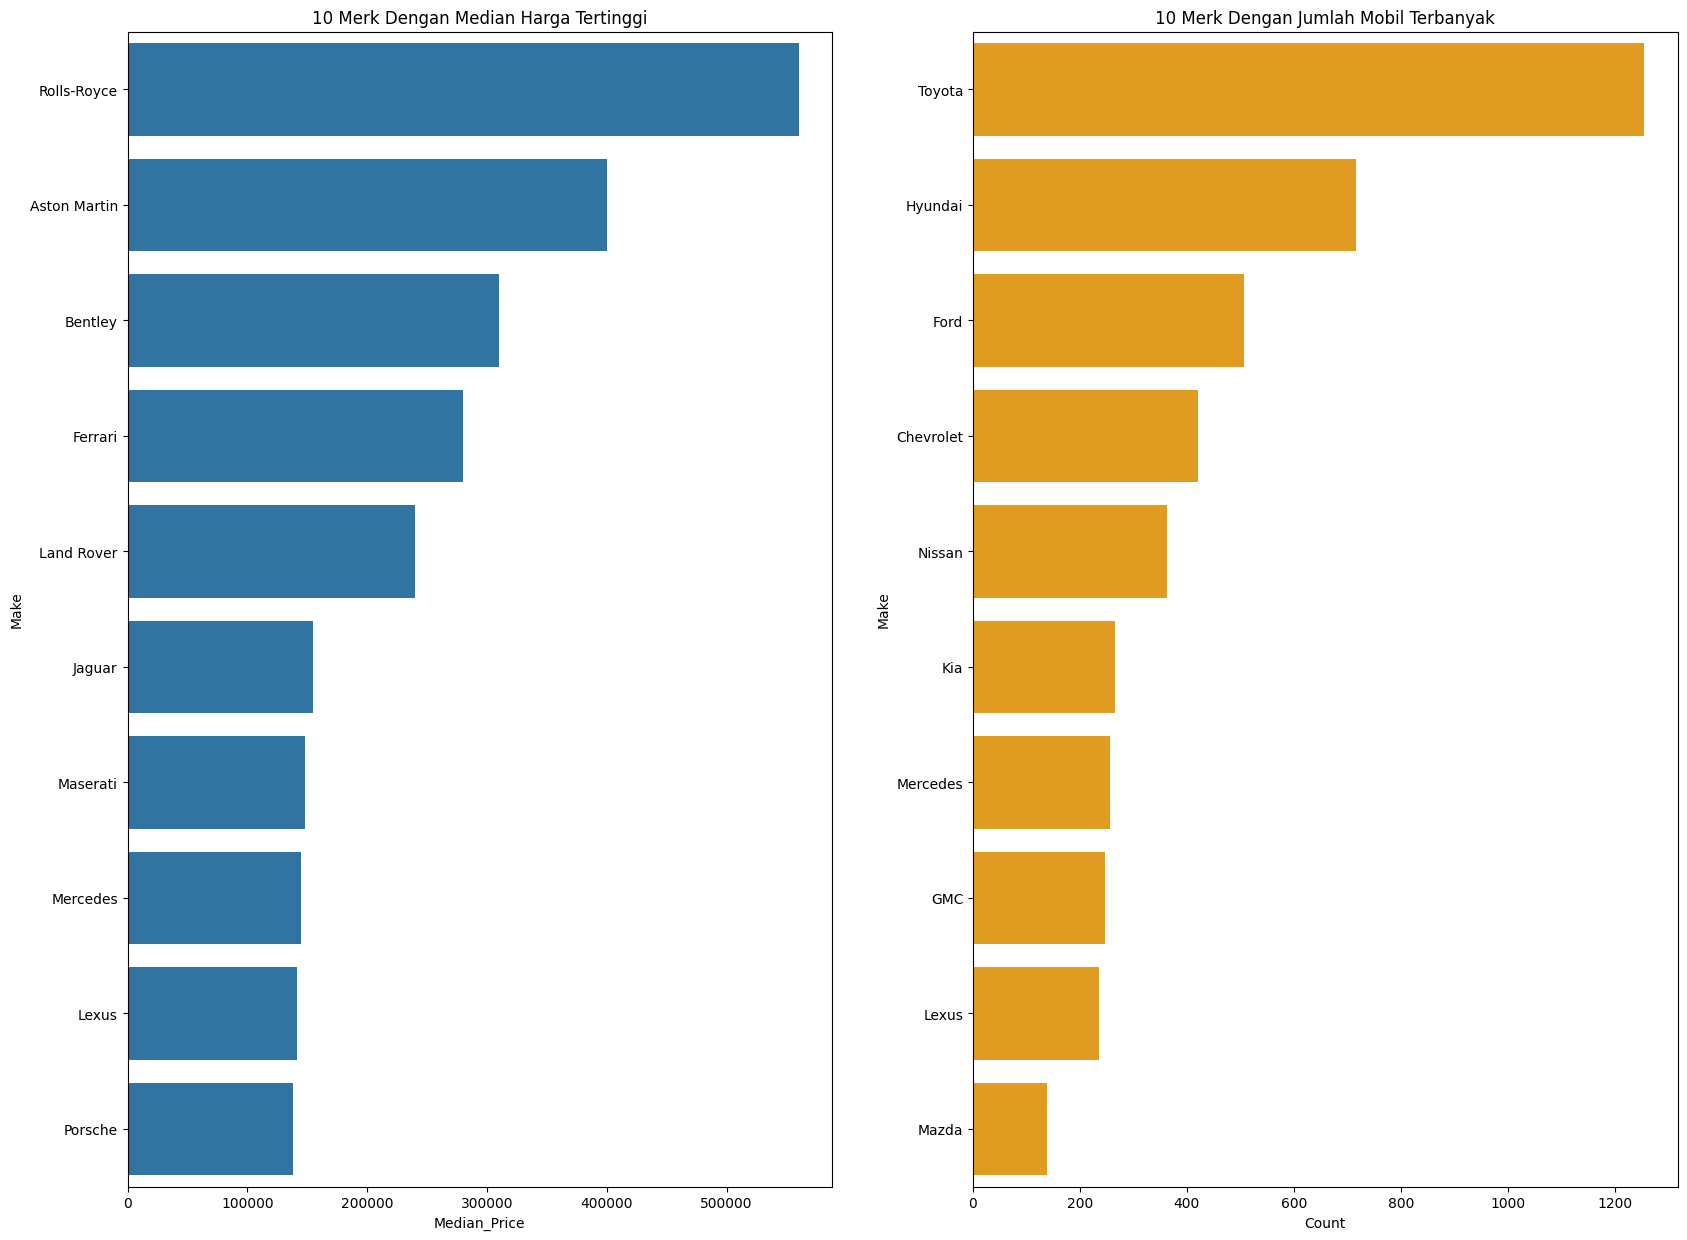

In [102]:
fig, axes= plt.subplots(figsize=(20,15), nrows=1, ncols=2)

sns.barplot(df_make.head(10), x='Median_Price', y='Make', ax=axes[0])
sns.barplot(df_make.sort_values(by='Count', ascending=False).head(10), x='Count', y='Make', ax=axes[1], color='orange')

axes[0].set_title("10 Merk Dengan Median Harga Tertinggi")
axes[1].set_title("10 Merk Dengan Jumlah Mobil Terbanyak")

plt.show()

- Roll-Royce menjadi mobil dengan median harga tertinggi, sedangkan Toyota adalah mobil terbanyak yang dijual di situs.

- Walaupun Mercedes dan Lexus merupakan merk mobil mewah, dua merk mobil tersebut termasuk kedalam 10 mobil terbanyak di situs.

- Terdapat merk mobil mewah yang dimiliki orang banyak walaupun harganya yang tinggi

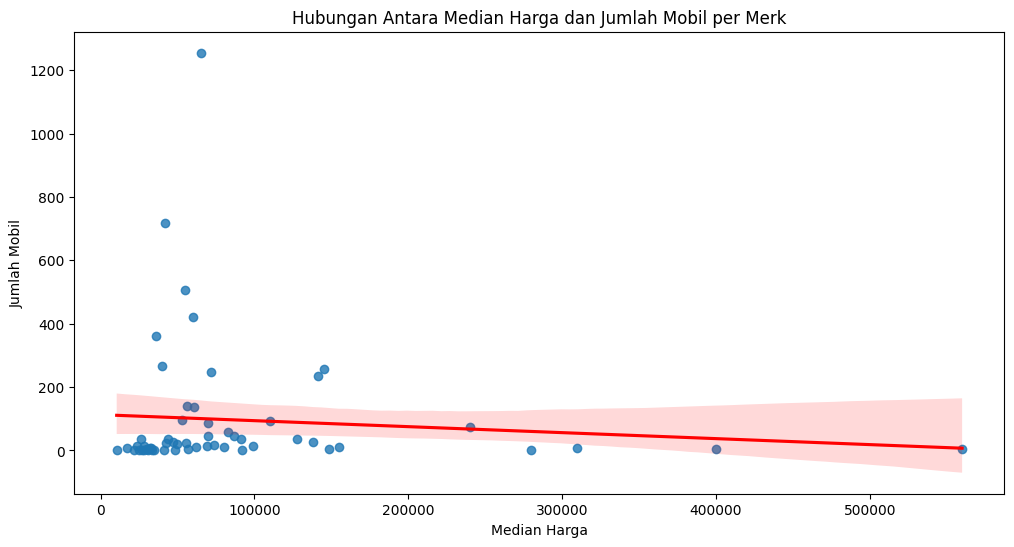

In [103]:
plt.figure(figsize=(12, 6))

sns.regplot(data=df_make, x='Median_Price', y='Count', line_kws={'color':'red'})

plt.title("Hubungan Antara Median Harga dan Jumlah Mobil per Merk")
plt.xlabel("Median Harga")
plt.ylabel("Jumlah Mobil")
plt.show()

- Regplot menunjukan adanya hubungan negatif diantara jumlah mobil bekas yang beredar di situs dengan median harga, semakin sedikit jumlah mobil maka semakin tinggi median harganya

- Nilai median harga yang tinggi dapat dikelompokkan sebagai mobil merk mewah. Merk mobil mewah sangat mengedepankan ekslusifitas, maka jumlahnya pun lebih sedikit dibandingkan mobil merk lain. Pada sisi lain, mobil yang bukan berasal dari merk mobil mewah, cenderung lebih umum digunakan dan memiliki harga pasar yang lebih murah.

#### Analisis Spesifikasi Mobil

In [104]:
df_specs = df_eda[['Gear_Type', 'Fuel_Type', 'Price']]
df_specs_pivot = pd.pivot_table(df_specs, index='Gear_Type', columns='Fuel_Type', aggfunc='median', values='Price')

df_specs_pivot.plot.bar(stacked=True, figsize=(16, 8))

plt.title("Harga Median Mobil Berdasarkan Jenis Transmisi dan Jenis Bahan Bakar")
plt.xlabel("Jenis Transmisi")
plt.ylabel("Harga Median")

Text(0, 0.5, 'Harga Median')

- Mobil automatic terdiri dari mobil dengan jenis bahan bakar diesel, gas, dan hybrid sedangkan mobil manual hanya memiliki mobil dengan jenis bahan bakar diesel dan gas

- Mobil dengan jenis bahan bakar hybrid menjadi mobil dengan median harga tertinggi, disusul oleh mobil diesel dan mobil gas

- Mobil automatic cenderung memiliki harga yang lebih mahal dibandingkan mobil manual

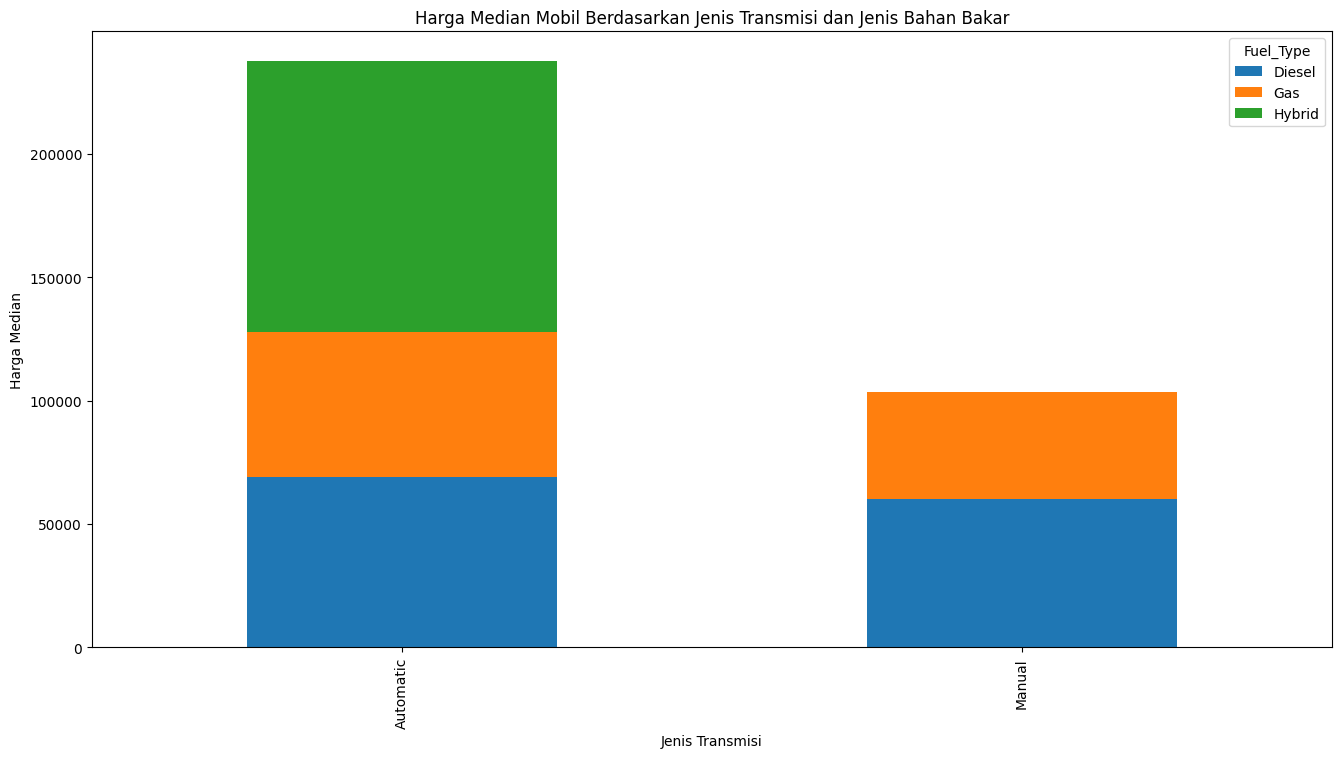

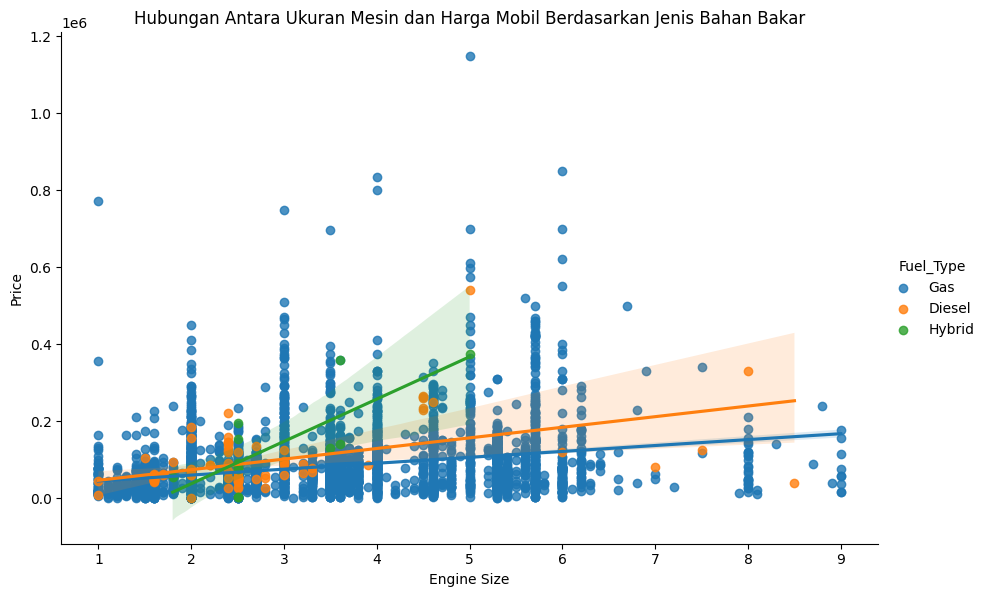

In [105]:
sns.lmplot(data=df_eda, x='Engine_Size', y='Price', hue='Fuel_Type', height=6, aspect=1.5)

plt.title("Hubungan Antara Ukuran Mesin dan Harga Mobil Berdasarkan Jenis Bahan Bakar")
plt.xlabel('Engine Size')
plt.ylabel('Price')

plt.show()

- Terdapat garis regresi yang mengarah ke kanan atas dalam hubungan antara ukuran mesin dan harga mobil, dimana mobil hybrid memiliki garis yang paling miring, disusul oleh mobil diesel dan gas

- Mobil Hybrid memiliki janglauan ukuran mesin yang kecil namun dengan harga yang lebih mahal, mobil diesel dan gas tersedia dengan jangkauan ukuran mesin yang lebih luas dan harga yang relatif lebih murah.

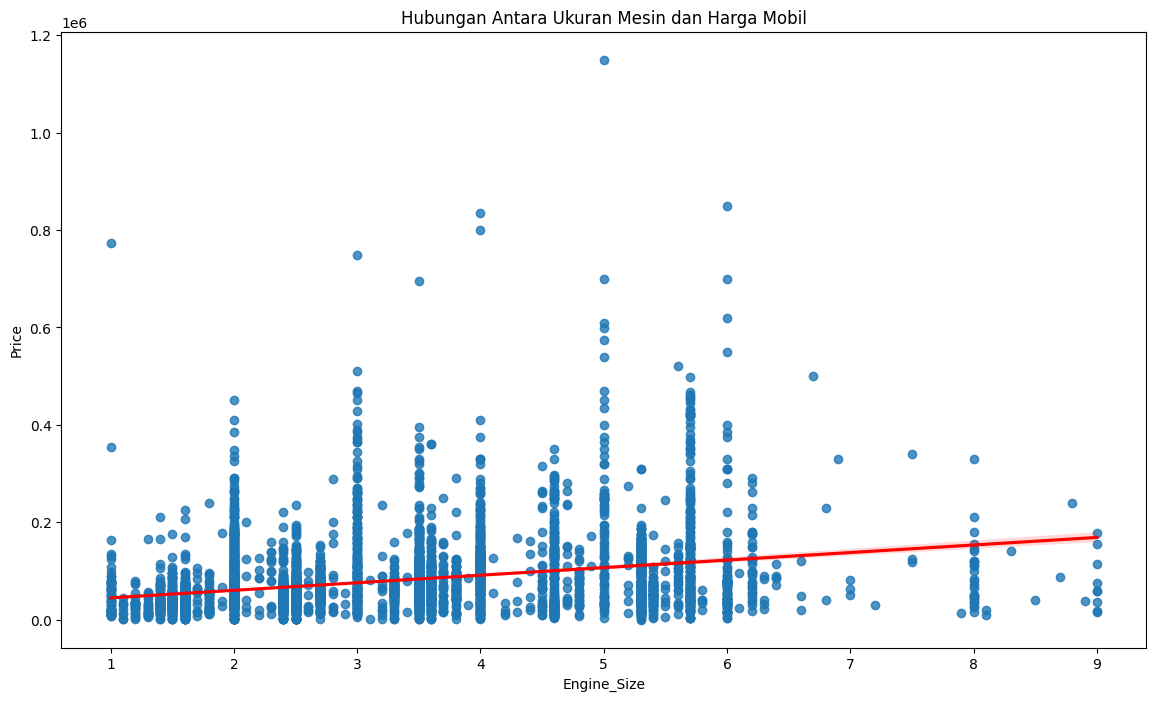

In [106]:
plt.figure(figsize=(14,8))

sns.regplot(data=df_eda, x='Engine_Size', y='Price', line_kws={'color':'red'})

plt.title('Hubungan Antara Ukuran Mesin dan Harga Mobil')
plt.show()

- Berdasarkan regplot, titik-titik yang tersebar tidak menunjukan sebuah pola yang koheren namun garis regresi mengarah keatas kanan. Terdapat indikasi hubungan yang positif ntara engine_size dengan harga mobil bekas.

#### Analisis Kondisi Pemakaian Mobil

In [107]:
fig, axes = plt.subplots(figsize=(16,8), nrows=1, ncols=2)

sns.scatterplot(df_eda, x='Mileage', y='Price', ax=axes[0])
sns.scatterplot(df_eda, x='Year', y='Price', ax=axes[1])

axes[0].set_title("Hubungan antara Mileage dan Harga Mobil")
axes[1].set_title("Hubungan antara Tahun dan Harga Mobil")

Text(0.5, 1.0, 'Hubungan antara Tahun dan Harga Mobil')

- Terdapat hubungan negatif terhadap harga degan riwayat jarak tempuh mobil. Semakin jauh jarak yang telah ditempuh oleh mobil, maka harga akan semakin turun

- Mobil yang lebih sering digunakan berdampak pada tingginya tingkat keausan komponen mobil, sehingga dinilai lebih murah.

- Terdapat hubungan positif antara tahun pembuatan mobil dengan harga

- Mobil keluaran baru memiliki usia pemakaian yang rendah dan memiliki risiko keausan pada komponen mobil yang lebih kecil, sehingga dinilai lebih mahal

In [108]:
plt.figure(figsize=(16,8))

sns.scatterplot(df_eda, x='Mileage', y='Year')
plt.ticklabel_format(style='plain', axis='both')
plt.title('Hubungan Antara Riwayat Jarak Tempuh dan Tahun Mobil')

Text(0.5, 1.0, 'Hubungan Antara Riwayat Jarak Tempuh dan Tahun Mobil')

- Data Mileage berdasarkan Year memiliki rentang yang sangat luas karena dipengaruhi oleh nilai outlier

- Terdapat data pada mileage dengan nilai ekstrem yang memiliki potensi dalam menurunkan tingkat keakuratan model ketika melakukan tes validasi

In [109]:
plt.figure(figsize=(16,8))

sns.histplot(df_eda['Mileage'])
plt.axvline(x=300000, color="red", linestyle="--", linewidth=2, label="Threshold")

plt.title("Distribusi data Mileage")
plt.ticklabel_format(style='plain', axis='both')

- Berdasarkan hasil riset, batas mileage wajar suatu mobil bekas adalah 300000 km, namun terdapat 3382 mobil bekas yang memiliki riwayat jarak tempuh diatas 300000 km. Sebelum dilakukan transaksi antara pihak Syarah.com dan seller, mobil bekas perlu melewati proses inspeksi yang cukup ketat karena Syarah.com sangat menjaga kualitas dari mobil yang akan dijual di websitenya, maka dari itu mobil dengan mileage tinggi sulit untuk lolos proses inspeksi.

- Mobil yang memiliki mileage diatas batas wajar dapat dikatakan anomali.

sumber : https://www.tomkadleckia.com/blog/good-mileage-preowned-car/?srsltid=AfmBOopRy-4qEBFkZ9Xms9Katy_13-8mS5IxEf4H8--36kd0aq9o9sx2

#### Analisis Spasial

In [110]:
print(f"{df_eda['Region'].unique()}")
print(f"Terdapat {df_eda['Region'].nunique()} nama kota yang ada pada kolom 'Region'")

['Riyadh' 'Jeddah' 'Dammam' 'Al-Medina' 'Qassim' 'Makkah' 'Jazan' 'Tabouk'
 'Aseer' 'Al-Ahsa' 'Taef' 'Sabya' 'Khobar' 'Abha' 'Al-Baha' 'Yanbu' 'Hail'
 'Al-Namas' 'Jubail' 'Al-Jouf' 'Hafar Al-Batin' 'Najran' 'Arar'
 'Wadi Dawasir' 'Besha' 'Qurayyat' 'Sakaka']
Terdapat 27 nama kota yang ada pada kolom 'Region'


Terdapat 27 nama yang berbeda pada kolom 'Region', sedangkan arab saudi hanya memiliki 13 provinsi. Hal ini terjadi karena terdapat value yang bukan merupakan provinsi di dalam kolom 'Region'

Tahapan selanjutnya adalah mengganti semua data yang bukan merupakan provinsi menjadi provinsi

In [ ]:
gdf_regions = gpd.read_file('Dataset/regions.geojson')
gdf_cities = gpd.read_file('Dataset/cities.geojson')

In [ ]:
gdf = pd.merge(gdf_cities, gdf_regions, on='region_id', how='left')
gdf = gdf[['region_id','name_en_x','geometry_x','name_en_y','geometry_y']]
gdf.rename(columns={'name_en_x':'city','geometry_x':'city geometry','name_en_y':'region','geometry_y':'region geometry'}, inplace=True)

gdf.head()

,region_id,city,city geometry,region,region geometry
0,7,Tabuk,POINT (36.53387 28.41464),Tabuk,GEOMETRYCOLLECTION (POLYGON ((37.40867 29.9123...
1,7,Na'mi,POINT (35.74931 28.30508),Tabuk,GEOMETRYCOLLECTION (POLYGON ((37.40867 29.9123...
2,1,Riyadh,POINT (46.73333 24.7),Riyadh,GEOMETRYCOLLECTION (POLYGON ((45.02997 27.6965...
3,7,Humayt,POINT (35.38013 28.65152),Tabuk,GEOMETRYCOLLECTION (POLYGON ((37.40867 29.9123...
4,2,At Taif,POINT (40.41667 21.26848),Makkah,GEOMETRYCOLLECTION (POLYGON ((40.60486 19.6395...


kita akan menggunakan GeoJSON berisikan informasi mengenai kota dan provinsi (region) di Arab Saudi sebagai data refrensi

sumber : https://github.com/homaily/Saudi-Arabia-Regions-Cities-and-Districts/tree/master

In [ ]:
df_eda[~df_eda['Region'].isin(gdf['region'])]['Region'].unique()

array(['Jeddah', 'Dammam', 'Al-Medina', 'Tabouk', 'Aseer', 'Al-Ahsa',
       'Taef', 'Sabya', 'Khobar', 'Abha', 'Al-Baha', 'Yanbu', 'Al-Namas',
       'Jubail', 'Al-Jouf', 'Hafar Al-Batin', 'Arar', 'Wadi Dawasir',
       'Besha', 'Qurayyat', 'Sakaka'], dtype=object)

Terdapat 11 nama pada kolom 'Region' yang tidak sesuai dengan nama pada data refrensi. Nama-nama tersebut akan disesuaikan dengan penamaan pada data refrensi agar tidak terjadi kesalahan ketika proses pencocokan data berlangsung

In [ ]:
city_mapping = {
    'Tabouk': 'Tabuk',
    'Wadi Dawasir': 'Wadi Ad Dawasir',
    'Khobar': 'Al Khobar',
    'Al-Medina': 'Madinah',
    'Aseer': 'Asir',
    'Taef': 'At Taif',
    'Al-Namas': 'An Namas',
    'Jubail': 'Al Jubail',
    'Al-Jouf': 'Jawf',
    'Besha': 'Bishah',
    'Qurayyat': 'Al Qurayyat'
}

df_eda['Region'] = df_eda['Region'].replace(city_mapping)

C:\Users\dwisanjani\AppData\Local\Temp\ipykernel_38644\1766071303.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eda['Region'] = df_eda['Region'].replace(city_mapping)


In [ ]:
# Clean function - keeps only letters and numbers
def clean_text(text):
    if isinstance(text, str):
        return re.sub(r'[^a-zA-Z0-9]', ' ', text).lower()
    return text

# Create mapping with cleaned keys
gdf['city_clean'] = gdf['city'].apply(clean_text)
city_to_region = dict(zip(gdf['city_clean'], gdf['region']))

# Apply to df_eda
df_eda['Region_clean'] = df_eda['Region'].apply(clean_text)
df_eda['Region'] = df_eda['Region_clean'].map(city_to_region).fillna(df_eda['Region'])

# Clean up
df_eda = df_eda.drop('Region_clean', axis=1)

C:\Users\dwisanjani\AppData\Local\Temp\ipykernel_38644\3015254091.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eda['Region_clean'] = df_eda['Region'].apply(clean_text)
C:\Users\dwisanjani\AppData\Local\Temp\ipykernel_38644\3015254091.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eda['Region'] = df_eda['Region_clean'].map(city_to_region).fillna(df_eda['Region'])


Dilakukan perubahan pada kolom region dengan mengganti semua data yang merupakan nama kota menjadi nama provinsinya

Text(0.5, 1.0, 'Median Harga Mobil per Region di Saudi Arabia')

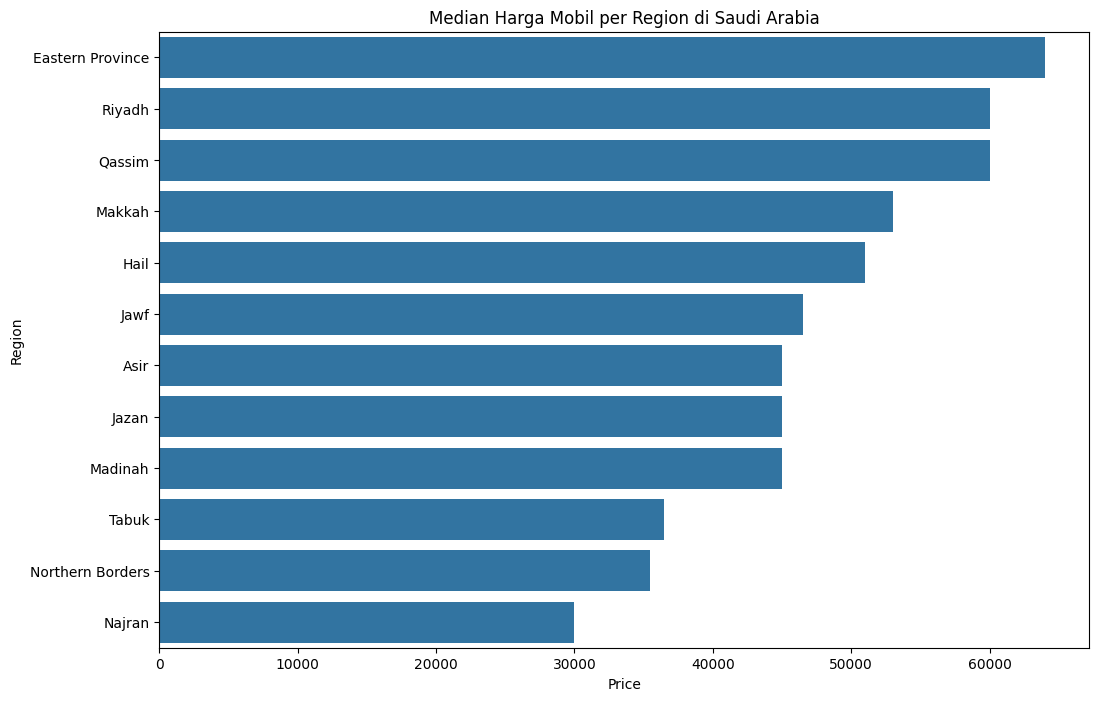

In [ ]:
df_map = df_eda.groupby('Region')['Price'].agg(['median', 'count']).reset_index()
df_map.columns = ['Region', 'Price', 'Count']

plt.figure(figsize=(12, 8))

sns.barplot(data=df_map.sort_values(by='Price', ascending=False), x='Price', y='Region')
plt.title("Median Harga Mobil per Region di Saudi Arabia")


Eastern province menjadi region dengan median harga mobil bekas tertinggi, sedangkan Najran adalah region dengan median harga mobil bekas paling rendah

In [ ]:
#Menghitung nilai korelasi antara jumlah mobil dengan median harga
corr = df_map['Count'].corr(df_map['Price'], method='spearman')
print(f"Nilai korelasi antara jumlah mobil dengan median harga mobil adalah {corr}")

Nilai korelasi antara jumlah mobil dengan median harga mobil adalah 0.7385343441312986


- Jumlah mobil yang beredar dengan median harga pada suatu area memiliki nilai korelasi sebesar 0.7

- Median harga setiap daerah berbeda karena memiliki ukuran pasar yang berbeda. Pasar mobil yang besar terjadi karena demand yang tinggi. Semakin tinggi permintaan pada suatu produk, semakin tinggi juga harga pasarnya

## Feature Correlations

In [ ]:
num_cols= ['Year', 'Engine_Size', 'Mileage', 'Price']

<Axes: >

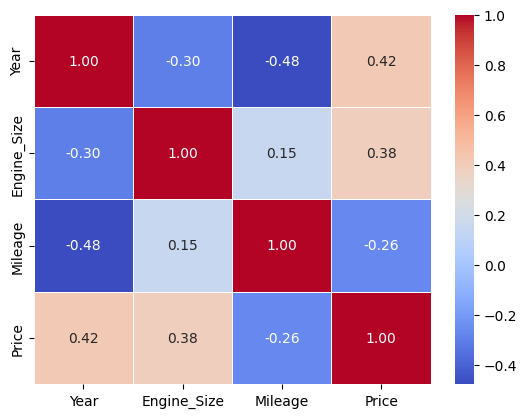

In [ ]:
corr = df_eda[num_cols].corr(method='spearman')

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

Tidak ada fitur yang memiliki nilai korelasi lebih dari 0.5 terhadap variabel target (harga), model memiliki potensi tingkat akurasi yang rendah ketika dilakukan data training dengan fitur-fitur yang ada.

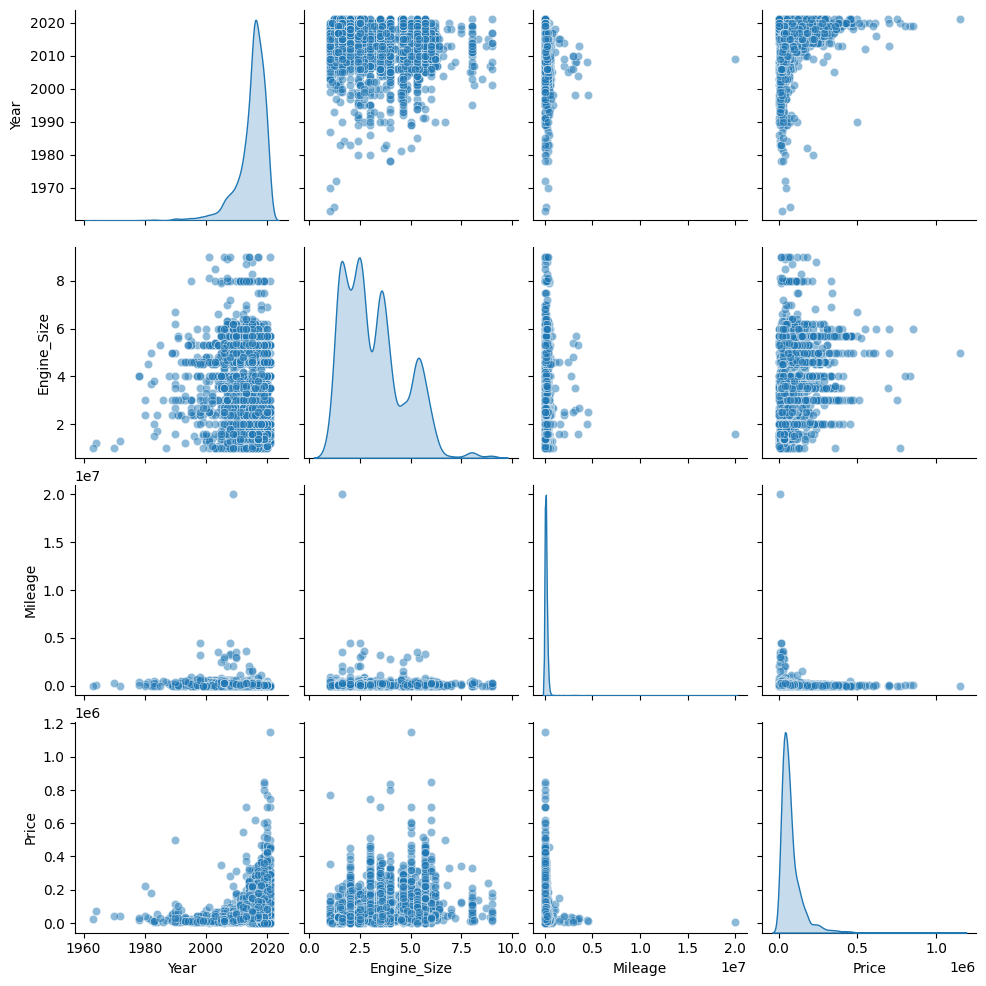

In [ ]:
fig = plt.Figure(figsize=(16,16))

sns.pairplot(df_eda[num_cols], diag_kind='kde', plot_kws={'alpha':0.5})

Pola penyebaran data pada scatterplot tiap fitur selain tahun pembuatan mobil terhadap harga cenderung datar, hal ini menunjukan bahwa tidak ada hubungan yang kuat antara fitur dengan variabel target. Data yang akan digunakan dinilai terlalu sederhana untuk proses data training sehingga terdapat kemungkinan terjadinya underfitting

# Data Preprocessing

## Karakteristik Model

Berdasarkan data understanding yang telah dilakukan, didapatkan bahwa:
- Data dari variabel target tidak terdistribusi secara normal
- Terdapat outlier yang terletak diatas upper bound dan dibawah lower bound
- Model memiliki potensi underfitting ketika dilakukan data training terhadap model

Berikut lima algoritma regresi yang dapat digunakan dalam proses model benchmarking untuk memilih model terbaik dalam memprediksi harga mobil bekas:

| Model | Kategori | Cara Kerja Singkat | Kelebihan | Kekurangan |
|---|---|---|---|---|
| **Linear Regression** | Linear Model | Memodelkan hubungan linear antara fitur dan target dengan mencari garis/bidang yang meminimalkan error kuadrat | Sederhana, cepat dilatih, mudah diinterpretasi | Tidak dapat menangkap hubungan non-linear yang kompleks antar fitur dan harga |
| **K-Nearest Neighbors (KNN) Regressor** | Instance-based | Memprediksi nilai target berdasarkan rata-rata nilai target dari K data tetangga terdekat di ruang fitur | Tidak butuh asumsi distribusi data, dapat menangkap pola non-linear sederhana | Sensitif terhadap skala fitur dan outlier, performa menurun pada dimensi fitur yang tinggi (curse of dimensionality) |
| **Decision Tree Regressor** | Tree-based | Membagi data secara rekursif berdasarkan fitur yang paling signifikan menurunkan error, membentuk struktur pohon keputusan | Mudah diinterpretasi, dapat menangkap hubungan non-linear dan interaksi antar fitur | Rentan overfitting jika pohon tidak dibatasi kedalamannya |
| **Random Forest Regressor** | Ensemble (Bagging) | Menggabungkan banyak decision tree yang dilatih pada subset data dan fitur berbeda secara acak, lalu merata-ratakan hasil prediksinya | Mengurangi overfitting dibanding single decision tree, lebih stabil dan robust terhadap outlier | Waktu training lebih lama, model lebih kompleks dan kurang mudah diinterpretasi dibanding satu pohon |
| **XGBoost Regressor** | Ensemble (Boosting) | Membangun pohon keputusan secara bertahap (sequential), dimana setiap pohon baru berusaha memperbaiki error dari pohon sebelumnya (gradient boosting) | Umumnya memberikan performa prediksi terbaik pada data tabular, mendukung regularisasi untuk mengurangi overfitting | Lebih kompleks untuk di-tuning (banyak hyperparameter), waktu training relatif lebih lama dibanding model sederhana |

Kelima model ini dievaluasi menggunakan metrik **RMSE**, **MAE**, dan **MAPE** melalui proses cross-validation untuk menentukan model dengan performa terbaik, yang kemudian dilanjutkan ke tahap hyperparameter tuning.

In [ ]:
df_model = df_eda.copy()

## Feature Engineering

### Handling Anomalies

Berdasarkan EDA yang telah dilakukan, terdapat data anomali pada fitur mileage dan target price

In [ ]:
(df_model['Mileage']>300000).sum()

np.int64(415)

In [ ]:
df_model = df_model[df_model['Mileage']<=300000]

Sebanyak 415 mobil memiliki mileage diatas batas wajar, yaitu 300000. Data-data tersebut tidak akan diikut sertakan dalam proses pemodelan agar model dapat mempelajari pattern data secara optimal

In [ ]:
(df_model['Price']<18500).sum()

np.int64(328)

In [ ]:
(df_model['Price']>765000).sum()

np.int64(5)

In [ ]:
df_model = df_model[df_model['Price']>=18500]
df_model = df_model[df_model['Price']<=765000]

Sebanyak 328 mobil memiliki harga dibawah batas wajar (18500), dan 5 mobil diatas harga wajar (765000). Data-data tersebut tidak akan diikut sertakan dalam proses pemodelan agar model dapat mempelajari pattern data secara optimal

### Handling Outliers

Seperti yang telah kita pahami, data terdistribusi secara tidak normal. Terdapat 'Skew' pada distribusi data target. Hal ini dapat memunculkan distorsi antara variabel dan menghasilkan koefisien bias dimana model terlalu fokus pada data mayoritas dan prediksi akan data minoritas menjadi tidak akurat. Hal ini tentunya sangat tidak diinginkan.

Distribusi data yang 'skewed' disebabkan oleh rentang data yang terlalu lebar karena adanya nilai ekstrem (outlier), maka dari itu perlu adanya tindakan terhadap nilai-nilai ekstrem tersebut.

Text(0.5, 0.98, 'Distribusi dan Boxplot Data Numerik')

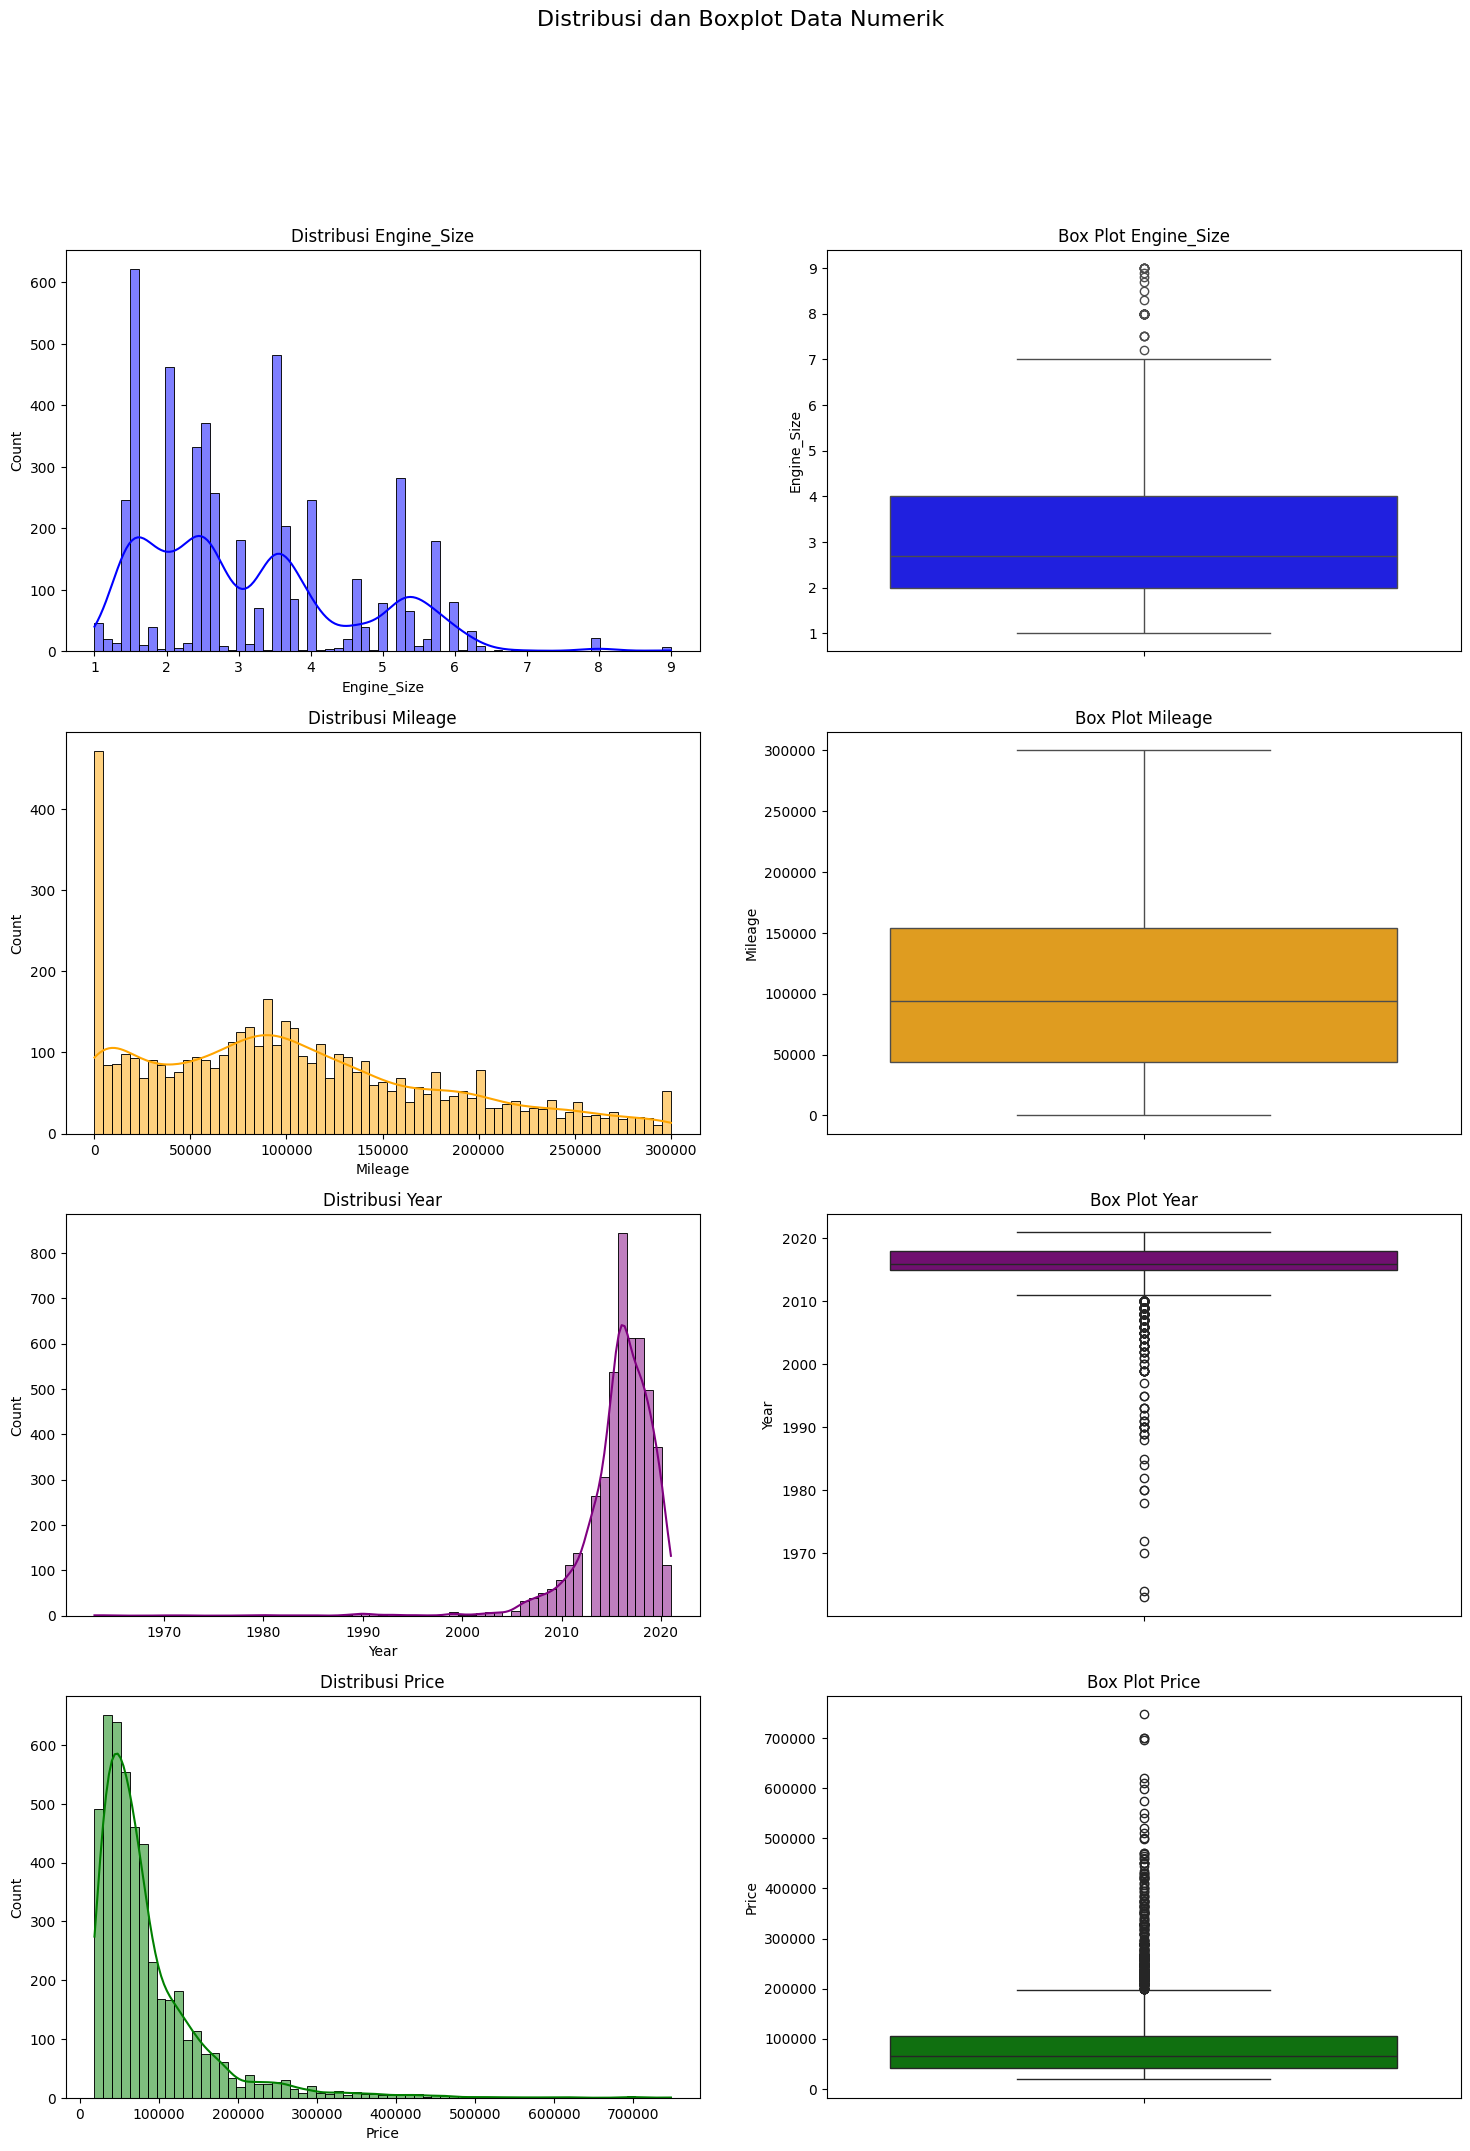

In [ ]:
num_cols = ['Engine_Size', 'Mileage', 'Year', 'Price']
colors = ['blue', 'orange', 'purple', 'green']

fig, axes = plt.subplots(len(num_cols), 2, figsize=(18, 6 * len(num_cols)))

for i, col in enumerate(num_cols):
    sns.histplot(df_model[col], bins=65, kde=True, ax=axes[i, 0], color=colors[i])
    axes[i, 0].set_title(f"Distribusi {col}")

    sns.boxplot(y=df_model[col], ax=axes[i, 1], color=colors[i])
    axes[i, 1].set_title(f"Box Plot {col}")
    
fig.suptitle("Distribusi dan Boxplot Data Numerik", fontsize=16)


In [ ]:
def outlier_stats(feature):
    q1 = df_model[feature].quantile(0.25)
    q3 = df_model[feature].quantile(0.75)
    iqr = q3 - q1
    limit = iqr * 1.5
    upper_bound = q3 + limit
    lower_bound = q1 - limit
    
    print(f'iqr: {iqr}')
    print(f'upper_bound: {upper_bound}')
    print(f'lower_bound: {lower_bound}')
    print(f"Jumlah outlier diatas upper bound pada {feature}: {(df_model[feature]>upper_bound).sum()}")
    print(f"Jumlah outlier dibawah lower bound pada {feature}: {(df_model[feature]<lower_bound).sum()}")

In [ ]:
outlier_stats('Engine_Size')

iqr: 2.0
upper_bound: 7.0
lower_bound: -1.0
Jumlah outlier diatas upper bound pada Engine_Size: 37
Jumlah outlier dibawah lower bound pada Engine_Size: 0


In [ ]:
outlier_stats('Mileage')

iqr: 109889.0
upper_bound: 318722.5
lower_bound: -120833.5
Jumlah outlier diatas upper bound pada Mileage: 0
Jumlah outlier dibawah lower bound pada Mileage: 0


In [ ]:
outlier_stats('Year')

iqr: 3.0
upper_bound: 2022.5
lower_bound: 2010.5
Jumlah outlier diatas upper bound pada Year: 0
Jumlah outlier dibawah lower bound pada Year: 331


In [ ]:
outlier_stats('Price')

iqr: 62500.0
upper_bound: 198250.0
lower_bound: -51750.0
Jumlah outlier diatas upper bound pada Price: 307
Jumlah outlier dibawah lower bound pada Price: 0


Hasil dari visualisasi outlier menunjukkan bahwa terdapat data dengan nilai diatas upper bound pada fitur- Engine_Size dan Year, serta variabel target yaitu Price.

In [ ]:
def outliers_trimming(df):
    df_clean = df.copy()
    
    for col in ['Engine_Size', 'Mileage', 'Year', 'Price']:
        q1 = df_clean[col].quantile(0.25)
        q3 = df_clean[col].quantile(0.75)
        iqr = q3 - q1
        limit = iqr * 1.5
        upper_bound = q3 + limit
        lower_bound = q1 - limit
            
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    
    return df_clean

In [ ]:
df_model = outliers_trimming(df_model)

Text(0.5, 0.98, 'Distribusi dan Boxplot Setelah Penanganan Outlier')

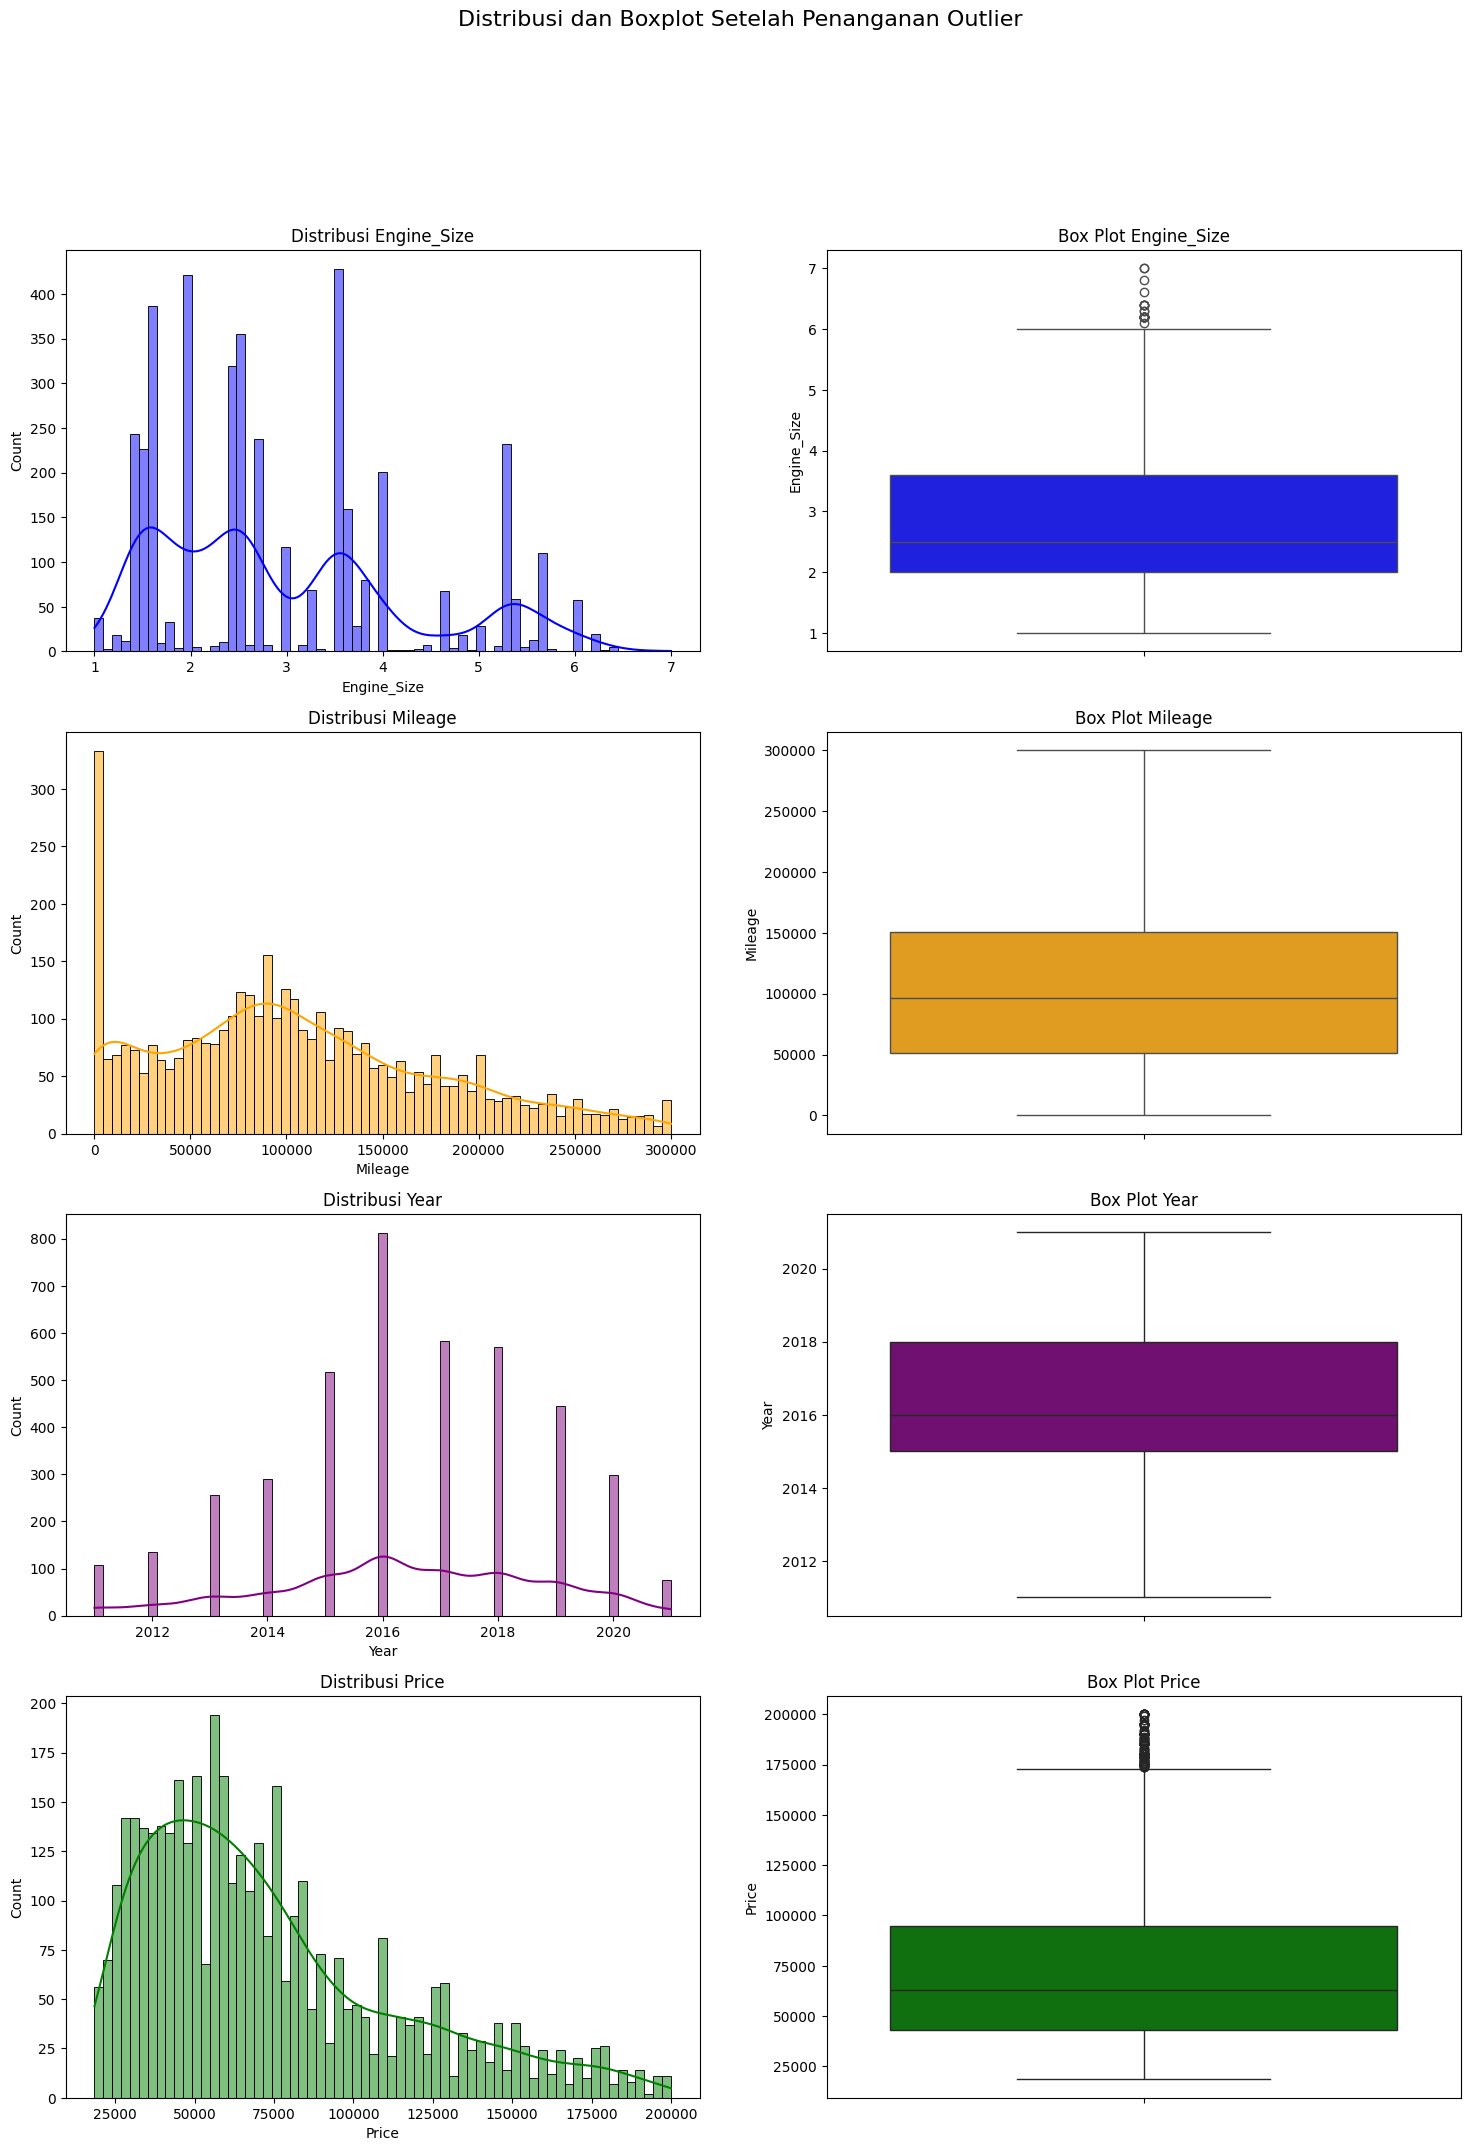

In [ ]:
fig, axes = plt.subplots(len(num_cols), 2, figsize=(18, 6 * len(num_cols)))

for i, col in enumerate(num_cols):
    sns.histplot(df_model[col], bins=65, kde=True, ax=axes[i, 0], color=colors[i])
    axes[i, 0].set_title(f"Distribusi {col}")

    sns.boxplot(y=df_model[col], ax=axes[i, 1], color=colors[i])
    axes[i, 1].set_title(f"Box Plot {col}")
    
fig.suptitle("Distribusi dan Boxplot Setelah Penanganan Outlier", fontsize=16)

## Preprocess Pipeline

In [ ]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4091 entries, 0 to 8034
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Make         4091 non-null   object 
 1   Type         4091 non-null   object 
 2   Year         4091 non-null   int64  
 3   Origin       4091 non-null   object 
 4   Color        4091 non-null   object 
 5   Options      4091 non-null   object 
 6   Engine_Size  4091 non-null   float64
 7   Fuel_Type    4091 non-null   object 
 8   Gear_Type    4091 non-null   object 
 9   Mileage      4091 non-null   int64  
 10  Region       4091 non-null   object 
 11  Price        4091 non-null   float64
dtypes: float64(2), int64(2), object(8)
memory usage: 415.5+ KB


Setelah memalui proses trimming dengan menghapus data anomali dan outlier, kita memiliki dataset dengan 4091 baris dan 12 kolom

In [ ]:
one_hot_cols = ['Gear_Type', 'Origin', 'Options', 'Fuel_Type'] #-> memiliki varias kategori yang sedikit
binary_cols = ['Make', 'Type', 'Color', 'Region'] #-> memiliki variasi kategori yang banyak

Berdasarkan hasil pengamatan di tahapn Data Understanding, fitur-fitur prediktor dibagi menjadi 2 kelompok, dimana fitur yang memiliki unique values sedikit dikelompokkan menjadi kolom one hot encoding, sementara fitur dengan unique values yang banyak dikelompokkan menjadi kolom binary

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('oh', OneHotEncoder(drop='first'), one_hot_cols),
        ('bin', BinaryEncoder(), binary_cols) 
    ], remainder='passthrough'
)

## Data Splitting

In [ ]:
features = df_model.drop('Price', axis=1)
target = df_model['Price']

X = features
y = target

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

# **Data Modelling**

## Model Benchmark

In [ ]:
#membuat function untuk benchmark model
def benchmark_model():

    #Memilih model yang akan digunakan untuk proses benchmark
    lr = LinearRegression()
    knn = KNeighborsRegressor()
    dt = DecisionTreeRegressor(random_state=42)
    rf = RandomForestRegressor(random_state=42)
    xgb = XGBRegressor(random_state=42)
    
    log_lr = TransformedTargetRegressor(regressor=lr, func=np.log1p, inverse_func=np.expm1)
    log_knn = TransformedTargetRegressor(regressor=knn, func=np.log1p, inverse_func=np.expm1)
    log_dt = TransformedTargetRegressor(regressor=dt, func=np.log1p, inverse_func=np.expm1)
    log_rf = TransformedTargetRegressor(regressor=rf, func=np.log1p, inverse_func=np.expm1)
    log_xgb = TransformedTargetRegressor(regressor=xgb, func=np.log1p, inverse_func=np.expm1)
    
    models = [log_lr, log_knn, log_dt, log_rf, log_xgb]
    
    scaler = StandardScaler()
    
    #membuat list kosong untuk menyimpan hasil cross validation tiap model
    #rmse
    score_rmse = []
    mean_rmse = []
    std_rmse = []
    #mae
    score_mae = []
    mean_mae = []
    std_mae = []
    #MAPE
    score_mape = []
    mean_mape = []
    std_mape = []

#iteration untuk melakukan cross validation pada tiap model
    for model in models:
        
        cv = KFold(n_splits=5, shuffle=True, random_state=42)
        
        #membuat pipeline estimator untuk preprocessing dan modeling
        estimator = Pipeline([
            ('preprocessing', preprocessor),
            ('scaler', scaler),
            ('model', model)
            ])
        
        #melakukan cross validation dengan metrics rmse, mae, mape, dan MAPE
        cv_rmse = cross_val_score(estimator, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error', error_score='raise')
        cv_mae = cross_val_score(estimator, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error', error_score='raise')
        cv_mape = cross_val_score(estimator, X_train, y_train, cv=cv, scoring='neg_mean_absolute_percentage_error', error_score='raise')
    
        #menyimpan hasil cross validation tiap model kedalam list
        score_rmse.append(cv_rmse)
        mean_rmse.append(np.mean(cv_rmse))
        std_rmse.append(np.std(cv_rmse))
        
        score_mae.append(cv_mae)
        mean_mae.append(np.mean(cv_mae))
        std_mae.append(np.std(cv_mae))
        
        score_mape.append(cv_mape)
        mean_mape.append(np.mean(cv_mape))
        std_mape.append(np.std(cv_mape))
    
    #membuat dataframe untuk menyimpan hasil benchmark model    
    metrics = pd.DataFrame({
        'Model': ['Linear Regression', 'KNN', 'Decision Tree', 'Random Forest', 'XGBoost'],
        'Mean RMSE': mean_rmse,
        'Std RMSE': std_rmse,
        'Mean MAE': mean_mae,
        'Std MAE': std_mae,
        'Mean MAPE': mean_mape,
        'Std MAPE': std_mape,
    })
    
    return metrics.sort_values(by='Mean MAPE', ascending=False)

In [ ]:
benchmark_model()

,Model,Mean RMSE,Std RMSE,Mean MAE,Std MAE,Mean MAPE,Std MAPE
4,XGBoost,-18509.921360,1537.841228,-11920.261141,820.940285,-0.171382,0.009017
3,Random Forest,-19065.154323,1576.154911,-12281.509311,621.084290,-0.176337,0.003136
1,KNN,-24571.334827,520.303964,-16881.153978,206.069151,-0.258853,0.005126
2,Decision Tree,-28099.131801,1247.142061,-17512.435145,775.412535,-0.266449,0.009586
0,Linear Regression,-27995.563646,1791.942917,-19237.126575,973.849466,-0.272281,0.005917


Hasil benchmark menunjukan bahwa XGBoost merupakan model yang memiliki performa terbaik, dilihat dari MEAN RMSE, MAE, dan MAPE yang paling rendah dibandingkan keempat model lainnya

In [ ]:
# Melakukan fitting pada model XGBoost
xgb = XGBRegressor(random_state=42)

score_rmse = []
score_mae = []
score_mape = []

scaler = StandardScaler()

# Prediksi pada test set

model = Pipeline([
    ('preprocessing', preprocessor),
    ('scaler', scaler),
    ('model', xgb)
    ])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
score_rmse.append(np.sqrt(mean_squared_error(y_test, y_pred)))
score_mae.append(mean_absolute_error(y_test, y_pred))
score_mape.append(mean_absolute_percentage_error(y_test, y_pred))

score_before_tuning = pd.DataFrame({'Model' : 'XGBoost', 'RMSE': score_rmse, 'MAE': score_mae, 'MAPE': score_mape})
score_before_tuning.sort_values(by='MAPE')

,Model,RMSE,MAE,MAPE
0,XGBoost,17322.489779,11973.177207,0.190365


## Hyperparameter Tuning


Model XGBoost dengan parameter default (random_state=42) belum tentu menghasilkan performa optimal untuk setiap dataset, karena karakteristik data (jumlah fitur, skala, tingkat noise, kompleksitas hubungan antar variabel) berbeda-beda pada setiap kasus. Hyperparameter tuning dilakukan untuk mencari kombinasi parameter yang paling sesuai dengan karakteristik data harga mobil bekas pada project ini.

In [ ]:
# Kedalaman pohon
max_depth = list(np.arange(1, 11))

# Learning rate
learning_rate = list(np.arange(1, 100)/100)

# Jumlah pohon
n_estimators = list(np.arange(100, 301, 5))

# Jumlah baris tiap pohon (% dari total baris train set)
subsample = list(np.arange(2, 10)/10)

# Gamma (min_impurity_decrease)
gamma = list(np.arange(1, 11)) # Semakin besar nilainya, semakin konservatif/simpel modelnya

# Jumlah feature yang digunakan untuk tiap pohon (% dari total kolom train set)
colsample_bytree = list(np.arange(1, 10)/10)

# Alpha (regularization)
reg_alpha = list(np.logspace(-3, 1, 10)) # Semakin besar nilainya, semakin konservatif/simpel modelnya


# Hyperparam space XGboost
hyperparam_space_xgb = {
    'model__max_depth': max_depth, 
    'model__learning_rate': learning_rate,
    'model__n_estimators': n_estimators,
    'model__subsample': subsample,
    'model__gamma': gamma,
    'model__colsample_bytree': colsample_bytree,
    'model__reg_alpha': reg_alpha
}

In [ ]:
# Benchmark model dengan hyperparameter tuning
xgb = XGBRegressor(random_state=42)

# Membuat algorithm chains
estimator_xgb = Pipeline([
        ('preprocessing', preprocessor),
        ('scaler', scaler),
        ('model', xgb)
        ])

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Hyperparameter tuning
random_xgb = RandomizedSearchCV(
    estimator_xgb, 
    param_distributions = hyperparam_space_xgb,
    n_iter = 100,
    cv = cv, 
    scoring = ['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error'], 
    n_jobs = -1,
    refit = 'neg_mean_absolute_percentage_error', # Hanya bisa memilih salah satu metric untuk optimisasi
    random_state = 42  
)

Proses tuning pada project ini menggunakan RandomizedSearchCV dengan refit='neg_mean_absolute_percentage_error', yang berarti kombinasi parameter dipilih secara spesifik untuk meminimalkan MAPE. Metrik yang paling relevan secara bisnis karena merepresentasikan persentase error yang mudah dipahami stakeholder (target MAPE < 20%). Tanpa tuning, model default belum tentu dioptimalkan untuk metrik yang paling penting bagi tujuan bisnis ini.


## Model Fitting

In [ ]:
# Fitting data training untuk mencari parameter terbaik
random_xgb.fit(X_train, y_train)

c:\Users\dwisanjani\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\externals\_numpydoc\docscrape.py:420: UserWarning: Unknown section Example
  self[section] = content


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [np.float64(0.1), np.float64(0.2), ...], 'model__gamma': [np.int64(1), np.int64(2), ...], 'model__learning_rate': [np.float64(0.01), np.float64(0.02), ...], 'model__max_depth': [np.int64(1), np.int64(2), ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","['neg_root_mean_squared_error', 'neg_mean_absolute_error', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'neg_mean_absolute_percentage_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`K

In [ ]:
random_xgb_result = pd.DataFrame(random_xgb.cv_results_).sort_values(by=['rank_test_neg_mean_absolute_percentage_error', 'rank_test_neg_mean_absolute_error', 'rank_test_neg_root_mean_squared_error']).head()
random_xgb_result

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__subsample,param_model__reg_alpha,param_model__n_estimators,param_model__max_depth,param_model__learning_rate,param_model__gamma,...,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error,split0_test_neg_mean_absolute_percentage_error,split1_test_neg_mean_absolute_percentage_error,split2_test_neg_mean_absolute_percentage_error,split3_test_neg_mean_absolute_percentage_error,split4_test_neg_mean_absolute_percentage_error,mean_test_neg_mean_absolute_percentage_error,std_test_neg_mean_absolute_percentage_error,rank_test_neg_mean_absolute_percentage_error
88,0.243212,0.001798,0.013205,0.000251,0.9,10.000000,285,6,0.07,5,...,467.488545,2,-0.171158,-0.180432,-0.183850,-0.169549,-0.172837,-0.175565,0.005575,1
98,0.382206,0.027961,0.010635,0.000674,0.3,1.291550,280,9,0.05,2,...,576.302209,1,-0.171007,-0.182997,-0.188207,-0.164524,-0.174294,-0.176206,0.008453,2
10,0.481175,0.010114,0.015102,0.000803,0.7,0.021544,210,9,0.06,5,...,448.710535,3,-0.174611,-0.183928,-0.184944,-0.175595,-0.172939,-0.178403,0.005009,3
91,0.183212,0.053377,0.012322,0.000387,0.6,0.001000,185,6,0.13,5,...,482.461158,5,-0.182441,-0.184411,-0.193258,-0.172891,-0.175423,-0.181685,0.007190,4
73,0.558196,0.010037,0.019133,0.001709,0.8,0.002783,280,9,0.04,10,...,389.986644,4,-0.181204,-0.188231,-0.187035,-0.175937,-0.180257,-0.182533,0.004543,5


In [ ]:
# Cek skor dan params terbaik
print('XGBoost')
print('Best_score:', random_xgb.best_score_)
print('Best_params:', random_xgb.best_params_)

XGBoost
Best_score: -0.17556535226588516
Best_params: {'model__subsample': np.float64(0.9), 'model__reg_alpha': np.float64(10.0), 'model__n_estimators': np.int64(285), 'model__max_depth': np.int64(6), 'model__learning_rate': np.float64(0.07), 'model__gamma': np.int64(5), 'model__colsample_bytree': np.float64(0.9)}


In [ ]:
# Define model terhadap estimator terbaik
xgb_tuning = random_xgb.best_estimator_

# Fitting model
xgb_tuning.fit(X_train, y_train)

# Predict test set
y_pred_xgb_tuning = xgb_tuning.predict(X_test)

# Simpan nilai metrics RMSE, MAE & MAPE setelah tuning
rmse_xgb_tuning = np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuning))
mae_xgb_tuning = mean_absolute_error(y_test, y_pred_xgb_tuning)
mape_xgb_tuning = mean_absolute_percentage_error(y_test, y_pred_xgb_tuning)

score_after_tuning = pd.DataFrame({'Model': 'XGBoost', 'RMSE': rmse_xgb_tuning, 'MAE': mae_xgb_tuning, 'MAPE': mape_xgb_tuning}, index=[0])
score_after_tuning

,Model,RMSE,MAE,MAPE
0,XGBoost,16039.470985,10917.132606,0.172499


## Model Performance

Setelah dilakukan hyperparameter tuning, yaitu mencari kombinasi parameter yang dapat menghasilkan model yang optimal dengan metode RandomizedSearch, didapatkan model XGBoost dengan tingkat error sebesar berikut

In [ ]:
score_comparison = pd.concat([score_before_tuning, score_after_tuning], ignore_index=True)
score_comparison.index = ['Before Tuning', 'After Tuning']
score_comparison

,Model,RMSE,MAE,MAPE
Before Tuning,XGBoost,17322.489779,11973.177207,0.190365
After Tuning,XGBoost,16039.470985,10917.132606,0.172499


Model dapat diterima karena telah memenuhi target berdasarkan metric yang telah ditetapkan

| **Metric** | **Result** | **Target** |
|---|---|---|
| **RMSE** | 16039.47 | < 20000 |
| **MAE** | 10917.13 | < 15000 |
| **MAPE** | 17.2% | < 20% |


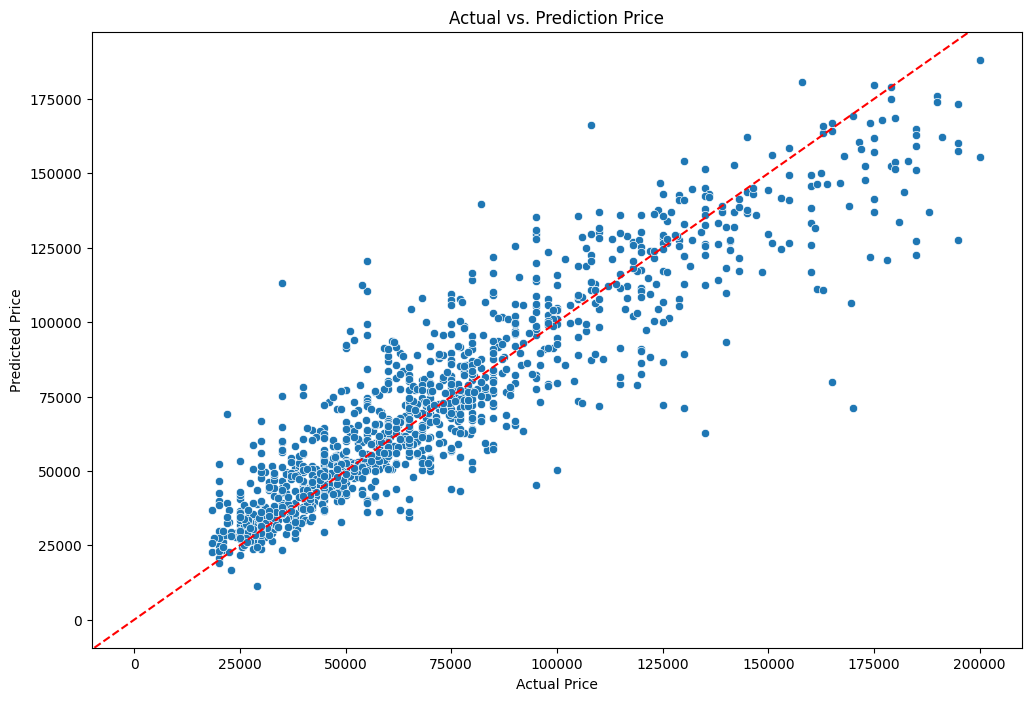

In [ ]:
plt.figure(figsize=(12, 8))

ax = sns.scatterplot(x=y_test, y=y_pred_xgb_tuning)

ax.set(title='Actual vs. Prediction Price', 
        xlabel='Actual Price', 
        ylabel='Predicted Price')

ax.axline((0, 0), slope=1, color="red", linestyle="--", linewidth=1.5)

- Sebagian besar titik data terkonsentrasi mengikuti garis diagonal, khususnya pada rentang harga rendah hingga menengah, hal ini membuktikan bahwa model mampu menangkap pola umum hubungan antar fitur dengan harga mobil dengan cukup baik.

- Sebaran titik semakin melebar (menjauhi garis ideal) seiring meningkatnya harga aktual, mengindikasikan model cenderung memiliki error yang lebih besar pada mobil dengan harga tinggi. Hal ini wajar terjadi karena data pada rentang harga tinggi cenderung lebih sedikit, sehingga model kurang terpapar pola pada segmen tersebut selama proses data training.

- Pola ini konsisten dengan nilai MAPE sebesar 17.2% yang didapat pada evaluasi model — error relatif masih dalam batas target (<20%), namun terdapat ruang perbaikan khususnya pada prediksi mobil dengan harga premium.

## Model Efficiency & Limitation

### Feature Importances

Text(0.5, 1.0, 'Feature Importances')

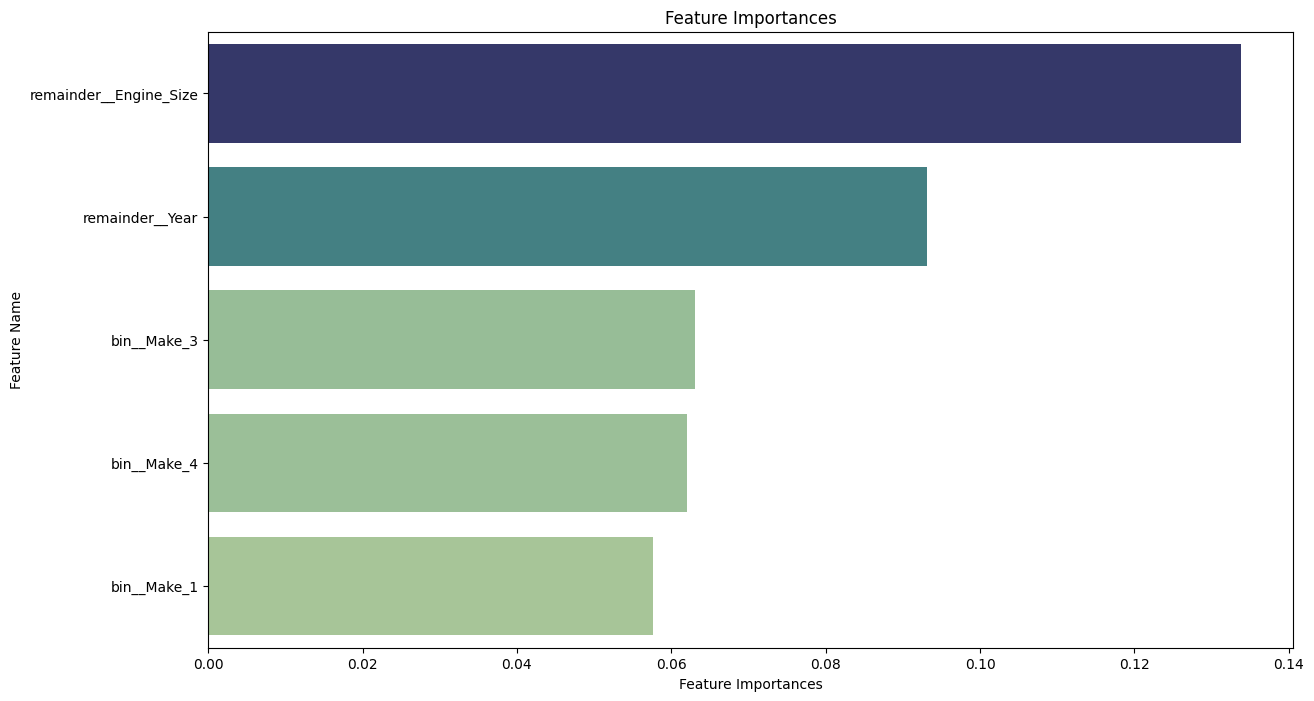

In [ ]:
fitted_model = xgb_tuning.named_steps['model']
fitted_preprocessor = xgb_tuning.named_steps['preprocessing']

feature_importances = fitted_model.feature_importances_
feature_names = fitted_preprocessor.get_feature_names_out()

df_feature_imp = pd.DataFrame({"Feature Name": feature_names,
                              "Feature Importances": feature_importances}).sort_values(by="Feature Importances",ascending=False).head()

plt.figure(figsize=(14,8))
sns.barplot(data=df_feature_imp,
            x='Feature Importances',
            y='Feature Name',
            hue="Feature Importances",
            palette="crest",
            legend=False)
plt.title("Feature Importances")

- Fitur Eninge_Size menempati posisi teratas, sejalan dengan temuan pada tahap EDA yang menunjukkan hubungan antara kedua fitur tersebut dengan harga mobil.

- Beberapa fitur kategorikal hasil binary-enocding (misalnya terkait merek/model tertentu) juga muncul sebagai kontributor penting, mengindikasikan bahwa brand/model kendaraan turut memengaruhi valuasi harga di pasar mobil bekas — konsisten dengan intuisi bisnis bahwa merek premium umumnya dihargai lebih tinggi.

- Perbedaan skor importance antar fitur teratas dengan fitur lainnya cukup signifikan, menunjukkan bahwa model sangat bergantung pada beberapa fitur dominan saja, sementara mayoritas fitur lain memberikan kontribusi marginal.

Feature importances ini bersifat global dan berbasis pada frekuensi/gain split di seluruh pohon, sehingga belum menjelaskan arah pengaruh (positif/negatif) tiap fitur. Hal ini akan diperjelas lebih lanjut melalui SHAP interpretation.

### SHAP Interpretation

In [ ]:
X_test_preprocessed = fitted_preprocessor.transform(X_test)

if scipy.sparse.issparse(X_test_preprocessed):
    X_test_preprocessed = X_test_preprocessed.toarray()

X_test_df = pd.DataFrame(X_test_preprocessed, columns=feature_names)

print(f"X_test shape: {X_test_df.shape} | Features: {len(feature_names)}")

# Sample data for SHAP
background = shap.sample(X_test_df, 100) 
X_sample = shap.sample(X_test_df, 100)

#menghitung shap value
explainer = shap.TreeExplainer(fitted_model, background)
shap_values = explainer.shap_values(X_sample)

print(f"SHAP values shape: {shap_values.shape}")

X_test shape: (1228, 33) | Features: 33
SHAP values shape: (100, 33)


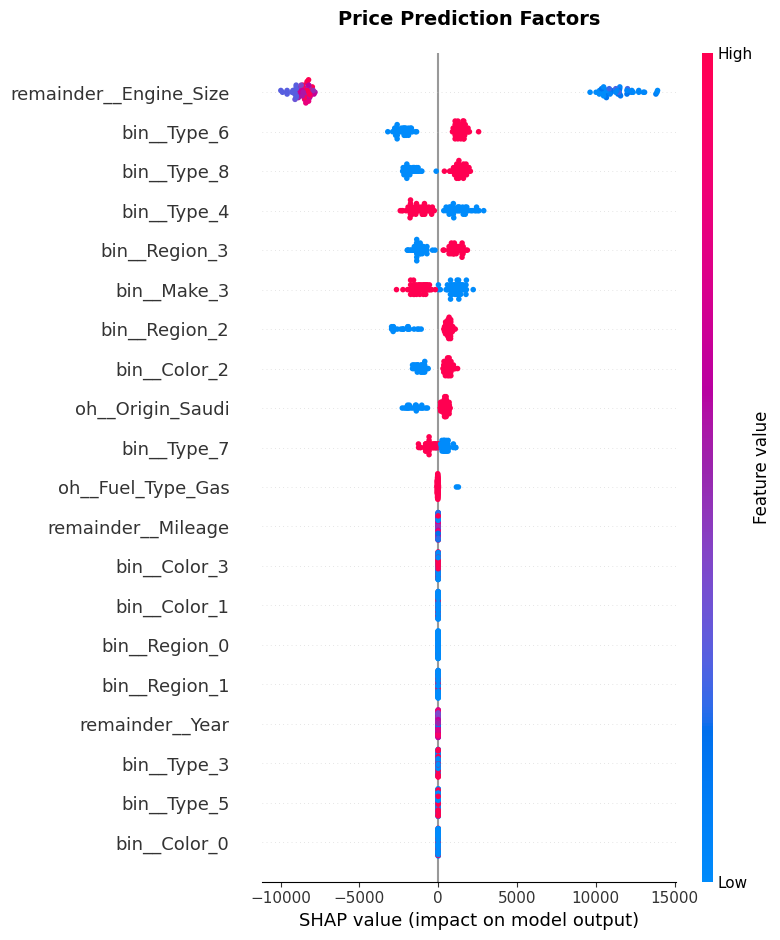

In [ ]:
plt.figure(figsize=(14, 8))

shap.summary_plot(shap_values,
                  X_sample,
                  feature_names=feature_names,
                  show=False)

plt.title('Price Prediction Factors', fontsize=14, pad=20, fontweight='bold')
plt.tight_layout()
plt.show()

SHAP summary plot memberikan interpretasi yang lebih detail dibandingkan feature importance biasa, karena plot ini menampilkan baik kemampuan fitur dalam mempengaruhi hasil prediksi secara indivisual maupun arah pengaruh setiap fitur terhadap prediksi harga.

- Fitur Engine_Size memiliki sebaran nilai SHAP yang paling lebar (kurang lebih -10.000 hingga +15.000), menegaskan statusnya sebagai fitur paling berpengaruh terhadap variasi harga prediksi, konsisten dengan hasil feature importance

- Menariknya, titik-titik berwarna biru (nilai Engine_Size rendah) cenderung berada di sisi kanan (SHAP value positif/menaikkan harga), sementara titik-titik berwarna merah muda (nilai Engine_Size tinggi) berada di sisi kiri (SHAP value negatif/menurunkan harga). Pola ini perlu dicermati lebih lanjut karena tidak sejalan dengan hasil EDA yang menunjukan adanya hubungan positif antara Engine_Size dengan Price. Hal ini kemungkinan disebabkan oleh skala/encoding Engine_Size pada tahap preprocessing (misalnya hasil scaling atau representasi yang tidak dalam satuan liter/cc standar), atau adanya interaksi dengan segmen mobil tertentu (misalnya mobil listrik dengan "engine size" kecil namun harga tinggi)

- Fitur-fitur kategorikal seperti Type, Region, dan Make menunjukkan sebaran SHAP yang lebih sempit namun tetap konsisten, mengindikasikan pengaruh yang stabil meski dengan SHAP Value yang kecil dibandingkan dengan Engine_Size

- Sebagian besar fitur di bagian bawah grafik (Mileage, Year, serta beberapa kategori Color/Region/Type lainnya) memiliki nilai SHAP yang mendekati nol, menandakan kontribusinya terhadap prediksi harga relatif minim dibanding fitur-fitur teratas

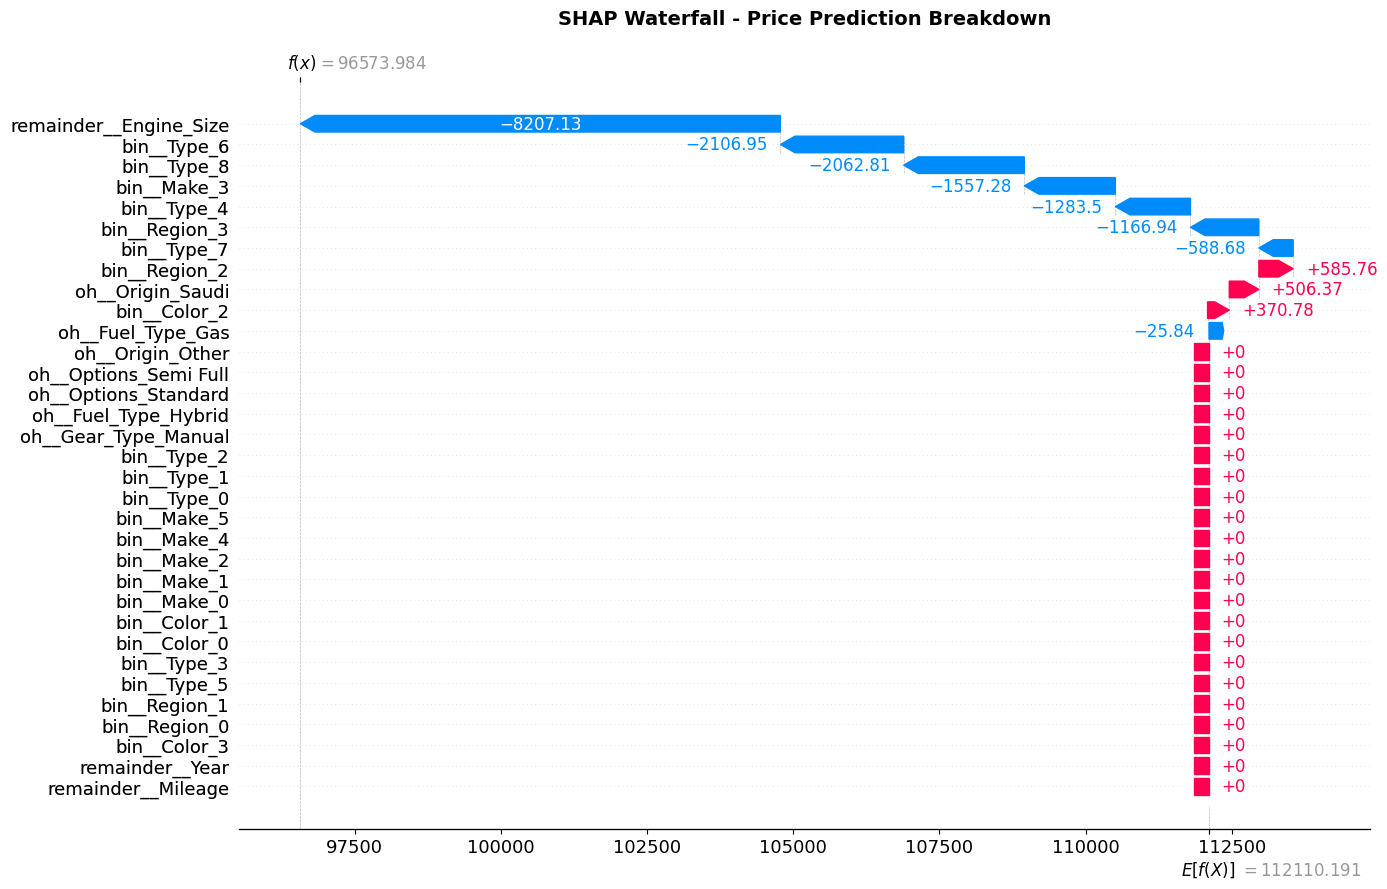

In [ ]:
# Membuat explanation object
explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    feature_names=feature_names
)

# waterfall plot
shap.plots.waterfall(
    explanation[0],
    show=False,
    max_display=len(feature_names))

fig = plt.gcf()
fig.set_size_inches(14, 9)

plt.title('SHAP Waterfall - Price Prediction Breakdown', fontsize=14, pad=20, fontweight='bold')
plt.tight_layout()
plt.show()

Waterfall plot menjelaskan kontribusi tiap fitur terhadap satu prediksi individual secara spesifik, dimulai dari nilai basis (*base value* — rata-rata prediksi model pada data sampel) hingga mencapai nilai prediksi akhir (f(x)) untuk observasi tersebut.

- Fitur dengan bar berwarna merah menunjukkan kontribusi yang menaikkan prediksi harga di atas base value, sementara bar berwarna biru menunjukkan kontribusi yang menurunkan prediksi harga

- Fitur-fitur dengan bar terpanjang (baik merah maupun biru) merupakan faktor paling berpengaruh dalam menentukan harga prediksi untuk observasi spesifik ini, umumnya didominasi oleh fitur numerik utama seperti Year dan Mileage

- Akumulasi seluruh kontribusi fitur (dari base value ditambah/dikurangi tiap kontribusi) menghasilkan nilai akhir f(x) yang merupakan output prediksi model untuk sampel tersebut, memberikan transparansi penuh atas bagaimana model "berpikir" dalam menghasilkan satu prediksi

- Interpretasi tingkat individual ini sangat berguna dari sisi bisnis, misalnya untuk menjelaskan kepada calon pembeli/penjual mengapa suatu mobil dihargai lebih tinggi atau lebih rendah dibanding rata-rata, sehingga meningkatkan transparansi dan kepercayaan terhadap sistem prediksi harga

# Business Impact

Analisis dampak bisnis dilakukan dengan simulasi terhadap 100 seller yang menolak offering perusahaan untuk mobilnya diakuisisi.

-  **SKENARIO 1 (Tanpa Machine Learning)** : Seluruh 100 seller yang menolak offering dari perusahaan melakukan proses inspeksi
- **SKENARIO 2 (Dengan Machine Learning)** : Model machine learning memberikan prediksi harga untuk 100 mobil seller yang menolak offering perusahaan terlebih dahulu

In [ ]:
# Asumsi semua biaya yang diperlukan
jumlah_seller = 100

biaya_inspeksi_manual = 100
waktu_inspeksi_manual_hari = 3

biaya_estimasi_ml = 10
waktu_estimasi_ml_menit = 5

NameError: name 'df_simulasi' is not defined

In [ ]:
# SKENARIO 1: TANPA ML — Seluruh 100 seller melalui inspeksi manual
biaya_proses_manual = jumlah_seller * biaya_inspeksi_manual
total_biaya_manual = biaya_proses_manual
total_waktu_manual_hari = jumlah_seller * waktu_inspeksi_manual_hari  # total hari kerja appraiser dibutuhkan

print("=== TANPA ML (Inspeksi Manual, 100 seller) ===")
print(f"Biaya proses inspeksi   : SAR {biaya_proses_manual:,.0f}")
print(f"Total biaya             : SAR {total_biaya_manual:,.0f}")
print(f"Total waktu proses      : {total_waktu_manual_hari} hari-kerja appraiser")

=== TANPA ML (Inspeksi Manual, 100 seller) ===
Biaya proses inspeksi   : SAR 10,000
Total biaya             : SAR 10,000
Total waktu proses      : 300 hari-kerja appraiser


In [ ]:
# SKENARIO 2: DENGAN ML — Model memberi prediksi harga untuk 100 seller
biaya_proses_ml = jumlah_seller * biaya_estimasi_ml
total_biaya_ml = biaya_proses_ml
total_waktu_ml_menit = jumlah_seller * waktu_estimasi_ml_menit

print("=== DENGAN ML (Estimasi Instan, 100 seller) ===")
print(f"Biaya proses estimasi        : SAR {biaya_proses_ml:,.0f}")
print(f"Total biaya                  : SAR {total_biaya_ml:,.0f}")
print(f"Total waktu proses           : {total_waktu_ml_menit} menit (~{total_waktu_ml_menit/60:.1f} jam)")

=== DENGAN ML (Estimasi Instan, 100 seller) ===
Biaya proses estimasi        : SAR 1,000
Total biaya                  : SAR 1,000
Total waktu proses           : 500 menit (~8.3 jam)


In [ ]:
# RINGKASAN PERBANDINGAN
ringkasan = pd.DataFrame({
    'Tanpa ML (Inspeksi Manual)': [biaya_proses_manual, total_biaya_manual, f"{total_waktu_manual_hari} hari"],
    'Dengan ML (Estimasi Instan)': [biaya_proses_ml, total_biaya_ml, f"{total_waktu_ml_menit} menit"]
}, index=['Biaya Proses (SAR)', 'Total Biaya (SAR)', 'Total Waktu Proses'])

print(ringkasan)

penghematan_biaya = total_biaya_manual - total_biaya_ml
print(f"\nPenghematan total biaya dengan ML untuk 100 seller : SAR {penghematan_biaya:,.0f}")

                   Tanpa ML (Inspeksi Manual) Dengan ML (Estimasi Instan)
Biaya Proses (SAR)                      10000                        1000
Total Biaya (SAR)                       10000                        1000
Total Waktu Proses                   300 hari                   500 menit

Penghematan total biaya dengan ML untuk 100 seller : SAR 9,000


Simulasi ini membandingkan dua skenario proses akuisisi mobil dari 100 seller, dengan risiko deviasi harga pada skenario ML dihitung dari selisih riil antara harga prediksi model dan harga aktual, sehingga merepresentasikan kondisi senyatanya berdasarkan hasil model.

- **Efisiensi biaya proses**: biaya inspeksi manual untuk 100 seller jauh lebih besar dibanding biaya estimasi ML untuk jumlah seller yang sama, karena proses manual membutuhkan biaya logistik dan tenaga appraiser untuk tiap unit, sedangkan ML dapat memproses seluruh seller secara otomatis dan paralel.

- **Efisiensi waktu**: proses inspeksi manual membutuhkan waktu berhari-hari untuk 100 seller (dihitung secara kumulatif dari waktu kerja appraiser), sedangkan ML dapat menyelesaikan estimasi untuk 100 seller hanya dalam hitungan jam, mempercepat pengalaman seller secara signifikan dan berpotensi meningkatkan retensi seller yang mengajukan penjualan.

- **Trade-off risiko harga**: proses manual diasumsikan sebagai harga acuan (tanpa risiko deviasi karena dinilai langsung dari kondisi fisik), sedangkan proses ML membawa risiko finansial berupa deviasi antara harga prediksi dan harga aktual pada tiap unit. Total risiko ini dihitung langsung dari hasil prediksi model pada 100 sampel data riil.

- **Keputusan bisnis**: ML layak digunakan apabila penghematan biaya proses lebih besar dari total risiko deviasi harga yang ditanggung. Berdasarkan hasil simulasi pada 100 sampel ini, penghematan biaya proses (SAR) dapat dibandingkan langsung dengan besaran risiko deviasi harga (SAR) untuk menentukan apakah trade-off ini menguntungkan secara agregat.

# Conclusions and Recommendations

### Conclusions

- Berdasarkan hasil dari Cost-Based Analysis terhadap 100 seller yang membatalkan proses akuisisi mobilnya oleh perusahaan, model machine learning hanya memakan biaya sebesar 1000 SAR, dibandingkan biaya yang harus dikeluarkan perusahaan ketika seller harus melalui proses inspeksi terlebih dahulu sebelum membatalkan prosesnya, yaitu 10000 SAR. Total biaya yang dapat dihemat oleh perusahaan pada analisis yang telah dilakukan sebesar 9000 SAR. Fitur estimasi harga mobil ini dapat membuat proses akuisisi mobil menjadi lebih efisien. Seller dapat mempertimbangkan keputusannya dalam melanjutkan proses bisnis berdasarkan gambaran harga yang diberikan oleh perusahaan.

- Faktor yang paling mendorong harga mobil untuk semakin naik adalah ukuran mesin yang kecil, sebaliknya jika ukuran mobil besar maka model cenderung memberikan prediksi harga yang lebih kecil. Selain itu model mobil yang berbeda, area listing mobil, dan merk dari mobil juga turut mempengaruhi hasil prediksi harga mobil secara signifikan.

- Model XGBoost berhasil memberikan performa yang optimal dalam memberikan prediksi harga mobil. Model mampu memberikan prediksi dengan MAPE 17,2%, RMSE 16039.47, dan MAE 10917.13 pada mobil yang berada dalam jangkauan harga 18.500 hingga 200.000. Pendekatan ini merupakan upaya forecasting harga dengan tingkat akurasi 'Good' berdasarkan Interpretation of MAPE for forecasting Accuracy (Lewis, 1982) dan mampu memberikan fitur estimasi yang dapat membantu seller memiliki gambaran akan harga mobilnya, sesuai dengan tujuan dari project ini.

### Recommendations

- Investigasi ulang fitur mileage dan target harga, data anomali dapat mengacaukan proses latihan model dalam mempelajari pola pada data. Monitor dan validasi kebenaran data agar model mampu menangkap hubungan antara fitur dengan target secara lebih akurat.

- Departmen operasional dan teknologi perlu melakukan A/B Testing untuk menguji coba fitur estimasi harga dengan pendekatan model machine learning terhadap sebagian seller sebagai grup treatment dan bandingkan dengan proses bisnis eksisting sebagai grup kontrol. Analisia hasil perbandingan conversion rate, waktu rata-rata proses bisnis, serta drop-off rate. Integrasikan model ke alur proses bisnis akuisisi mobil seller sebagai fitur estimasi harga real-time, tetap libatkan human review untuk transaksi bernilai tinggi, dan tampilkan hasil SHAP ke seller untuk meningkatkan transparansi.

- Monitor metrik RMSE/MAE/MAPE secara berkala untuk mendeteksi model drift, lakukan retraining dengan data terbaru, dan validasi asumsi dampak bisnis dengan data operasional riil perusahaan.

- Tim Data Engineering perlu memperkaya dataset dengan fitur eksternal (kondisi inspeksi, riwayat servis, harga kompetitor) dan eksplorasi prediction interval untuk memberikan rentang harga, bukan hanya satu angka estimasi.

# Model Deployment

In [ ]:
joblib.dump(xgb_tuning, 'price_prediction_model.pkl')

print("Model saved succesfully")

Model saved succesfully
